In this notebook, we will make some plots trying to show the different physical nature of ELG galaxies relative to BGS-B etc.


Notes: 
[OII] is typically strong in ELG
Ting-Wen Lan (10 mins) - The Diversity of ELG [OII] Line Profiles and its links to Star-formation and Morphology

In [155]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie


import numpy as np
import h5py
from astropy.table import Table
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Key emission lines for reference (rest-frame wavelengths in Angstroms)
emission_lines = {
    r"[OII] $\lambda$3727": 3727.0,
    r"H$\beta$": 4861.0,
    r"[OIII] $\lambda$4959": 4959.0,
    r"[OIII] $\lambda$5007": 5007.0,
    r"H$\alpha$": 6563.0,
    r"[NII] $\lambda$6584": 6584.0,
    r"[SII] $\lambda$6717": 6717.0,
    r"[SII] $\lambda$6731": 6731.0,
}

from elg_explore import load_catalog, load_spectra, select_sample, get_sample_spectra_with_halpha,  normalize_by_halpha_catalog, bootstrap_stack, bootstrap_stack_fast_capped

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Rebin the redshift

In [156]:
# from elg_explore import deredshift_for_stacking

In [157]:
# deredshift_for_stacking()

### Stacking the spectra

In [158]:
sample_colors = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }


In [159]:

# Load data
print("\n[1] Loading catalog...")
tot_cat = load_catalog()
print(f"    Total galaxies after masking: {len(tot_cat)}")

print("\n[2] Loading spectra...")
spectra_data = load_spectra()
print(f"    Total spectra loaded: {len(spectra_data['targetid'])}")

wave = spectra_data["wave_rest"]
print(f"    Wavelength range: {wave.min():.1f} - {wave.max():.1f} Angstroms")



[1] Loading catalog...
Total catalog size = 368807
Cleaned catalog size = 328094
    Total galaxies after masking: 328094

[2] Loading spectra...
    Total spectra loaded: 368807
    Wavelength range: 3600.0 - 9819.0 Angstroms


In [6]:
## regen the wave spectra again and resample to some common wave grid like 0.5?

## Make two plots here:

1) Comparing with BGS-Bright galaxies in the same redshift slice, and conditioning it on being blue g-r < 0.2, what is the r-z distribution look like? Do this at two different redshifts z=0.1 and z=0.3
- make a note in the paper that the higher redshift tail, the photometry is uncertain, stellar mass estimates could be wrong, and AGN contribution not considered, so would be careful when using those high-redshift ELGs
- Make this comparison without any dwarf cut, but the blue lowz ones are likely to be dwarf. There is no BGS B dwarf at z=0.3, so hard to compare to

2) Use the k-corrected photometry to see how the rest-frame colors look like for these objects!


  

In [ ]:
bgsb_cat_all = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/catalog_for_lena/desi_y1_clean_bgsb_bgsf_lowz_data.fits")
bgsb_cat_all = bgsb_cat_all[(bgsb_cat_all["SAMPLE"] =="BGS_BRIGHT") & (bgsb_cat_all["SPECTYPE"] == "GALAXY") & (bgsb_cat_all["DELTACHI2"] > 40)]



In [129]:
len(bgsb_cat_all)

4326791

In [134]:
## now we will plot the color distribution in different redshifts

lowz_slice = (np.abs(bgsb_cat_all["Z"] - 0.1) < 0.01)
hiz_slice = (np.abs(bgsb_cat_all["Z"] - 0.3) < 0.01)


In [136]:
gr_bgsb = bgsb_cat_all["MAG_G"].data - bgsb_cat_all["MAG_R"].data
rz_bgsb = bgsb_cat_all["MAG_R"].data - bgsb_cat_all["MAG_Z"].data


In [183]:
## select from the dwarf sample now!
noelg_lowz = select_sample(tot_cat, "NO_ELG", z_min=0.1-0.01, z_max=0.1+0.01)
elg_lowz = select_sample(tot_cat, "ELG", z_min=0.1-0.01, z_max=0.1+0.01)

rz_lowz_elg = elg_lowz["MAG_R"].data - elg_lowz["MAG_Z"].data
rz_lowz_noelg = noelg_lowz["MAG_R"].data - noelg_lowz["MAG_Z"].data

gr_lowz_elg = elg_lowz["MAG_G"].data - elg_lowz["MAG_R"].data
gr_lowz_noelg = noelg_lowz["MAG_G"].data - noelg_lowz["MAG_R"].data


Total number selected = 17547
Total number selected = 18946


In [184]:
elg_hiz = select_sample(tot_cat, "ELG", z_min=0.3-0.01, z_max=0.3+0.01)

rz_hiz_elg = elg_hiz["MAG_R"].data - elg_hiz["MAG_Z"].data
gr_hiz_elg = elg_hiz["MAG_G"].data - elg_hiz["MAG_R"].data


Total number selected = 5006


In [198]:
np.percentile(gr_hiz_elg,95)

0.3974947929382324

In [197]:
np.percentile(gr_lowz_elg,95)

0.29085540771484375

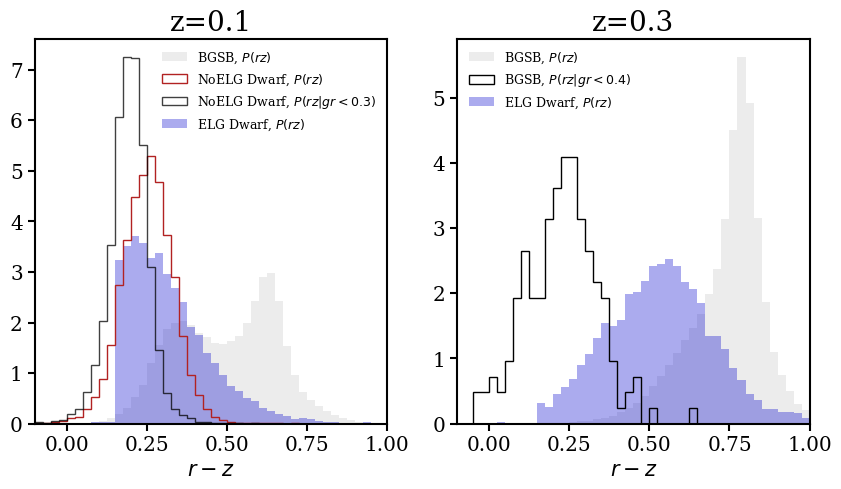

In [202]:
fig,ax = plt.subplots(1,2,figsize = (10,5))

ax[0].set_title("z=0.1",fontsize = 20)

#plot the bgsb full color dist
ax[0].hist(rz_bgsb[lowz_slice],range=(-0.5,2),bins=100,histtype="stepfilled",density=True, label = r"BGSB, $P(rz)$",color="grey",alpha=0.15)
# ax[0].hist(rz_bgsb[lowz_slice & (gr_bgsb < 0.2)],range=(-0.5,2),bins=100,histtype="step",density=True, label = r"BGSB, $P(rz | gr < 0.2)$", color="k")

#plot the dwarf color dist
ax[0].hist(rz_lowz_noelg,range=(-0.5,2),bins=100,histtype="step",density=True, label = r"NoELG Dwarf, $P(rz)$",color="firebrick",alpha=1)
ax[0].hist(rz_lowz_noelg[gr_lowz_noelg < 0.3],range=(-0.5,2),bins=100,histtype="step",density=True, label = r"NoELG Dwarf, $P(rz|gr < 0.3)$",color="k",alpha=0.75,lw=1)

ax[0].hist(rz_lowz_elg,range=(-0.5,2),bins=100,histtype="stepfilled",density=True, label = r"ELG Dwarf, $P(rz)$",color="mediumblue",alpha=0.33)


ax[1].set_title("z=0.3",fontsize = 20)
#for bgsb full color dist
ax[1].hist(rz_bgsb[hiz_slice],range=(-0.5,2),bins=100,histtype="stepfilled",density=True, label = r"BGSB, $P(rz)$",color="grey",alpha=0.15)
ax[1].hist(rz_bgsb[hiz_slice & (gr_bgsb < 0.4)],range=(-0.5,2),bins=100,histtype="step",density=True, label = r"BGSB, $P(rz|gr < 0.4)$",color="k")

#for dwarf elg color dist
ax[1].hist(rz_hiz_elg,range=(-0.5,2),bins=100,histtype="stepfilled",density=True, label = r"ELG Dwarf, $P(rz)$",color="mediumblue",alpha=0.33)

for axi in ax:
    axi.set_xlim([-0.1,1])
    axi.legend(frameon=False,fontsize = 9)
    axi.set_xlabel(r"$r-z$",fontsize = 15)
    
plt.show()



In [224]:
## plot this is as 2d color dist!!

In [7]:
# fig,ax = plt.subplots(1,2,figsize = (10,5))

# ax[0].set_title("z=0.1",fontsize = 20)

# #plot the bgsb full color dist
# ax[0].hist2d(gr_bgsb[lowz_slice], rz_bgsb[lowz_slice],range=((-0.5,2), (-0.5,2)),bins=100,histtype="stepfilled",density=True,cmap="Greys")

# # ax[0].hist(rz_bgsb[lowz_slice & (gr_bgsb < 0.2)],range=(-0.5,2),bins=100,histtype="step",density=True, label = r"BGSB, $P(rz | gr < 0.2)$", color="k")

# #plot the dwarf color dist
# # ax[0].hist(rz_lowz_noelg,range=(-0.5,2),bins=100,histtype="step",density=True, label = r"NoELG Dwarf, $P(rz)$",color="firebrick",alpha=1)
# # ax[0].hist(rz_lowz_noelg[gr_lowz_noelg < 0.3],range=(-0.5,2),bins=100,histtype="step",density=True, label = r"NoELG Dwarf, $P(rz|gr < 0.3)$",color="k",alpha=0.75,lw=1)
# # ax[0].hist(rz_lowz_elg,range=(-0.5,2),bins=100,histtype="stepfilled",density=True, label = r"ELG Dwarf, $P(rz)$",color="mediumblue",alpha=0.33)

# ax[0].set_xlim([-0.1,1])
# ax[0].set_ylim([-0.1,1])

# # for axi in ax:
# #     axi.set_xlim([-0.1,1])
# #     axi.legend(frameon=False,fontsize = 9)
# #     axi.set_xlabel(r"$r-z$",fontsize = 15)
    
# plt.show()



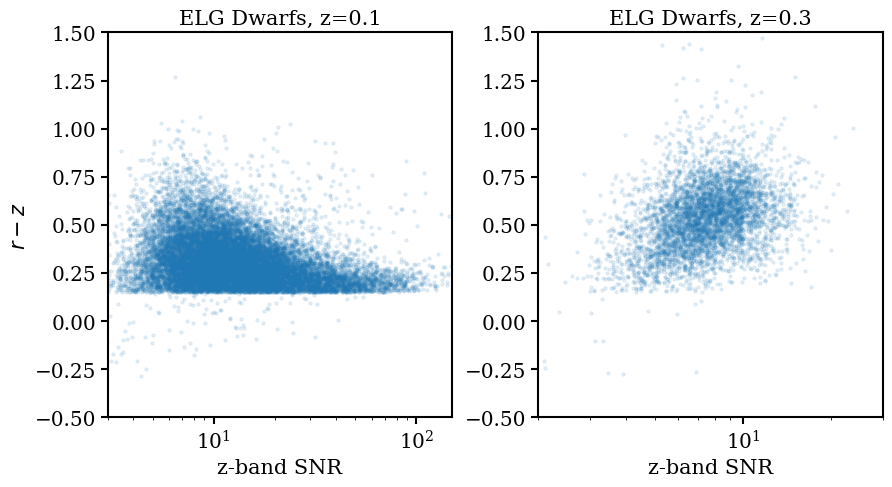

In [218]:
rz_lowz = elg_lowz["MAG_R"].data - elg_lowz["MAG_Z"].data
snr_z_lowz = elg_lowz["FLUX_Z"].data * np.sqrt(elg_lowz["FLUX_IVAR_Z"].data)

rz_hiz = elg_hiz["MAG_R"].data - elg_hiz["MAG_Z"].data
snr_z_hiz = elg_hiz["FLUX_Z"].data * np.sqrt(elg_hiz["FLUX_IVAR_Z"].data)

##plotting now 

fig,ax = plt.subplots(1,2,figsize = (10,5))
plt.subplots_adjust(wspace=0.25)

ax[0].set_title("ELG Dwarfs, z=0.1",fontsize = 15)
ax[1].set_title("ELG Dwarfs, z=0.3",fontsize = 15)

ax[0].set_xlabel("z-band SNR",fontsize = 15)
ax[1].set_xlabel("z-band SNR",fontsize = 15)

ax[0].set_ylabel(r"$r-z$",fontsize = 15)

ax[0].scatter(snr_z_lowz,rz_lowz,s=5,alpha=0.1 )
ax[1].scatter(snr_z_hiz,rz_hiz,s=5,alpha=0.1 )

ax[0].set_xlim([3,150])
ax[1].set_xlim([2,30])

for axi in ax:
    axi.set_xscale("log")
    axi.set_ylim([-0.5,1.5])
    
plt.show()

Thoughts:

We consider two redshift points to do our comparison, one at z=0.1 and the other at z=0.3

1) In the right panel in the first plot, we are plotting the r-z color distribution of various samples. Most importantly, the blue filled distribution is the ELG dwarfs at z=0.1 r-z color distribution. The other important dist is the r-z color distribution of non-elg dwarfs, conditioned on it being blue, that is g-r < 0.3. This limit is the 95% percentile of g-r color of ELG dwarfs at this redshift so we use that for comparison. We see that even though the ELG r-z dist is more extended to high r-z (no low r-z tail due to ELG color cut), they peak at similar values. Furthermore, the wider ELG distribution is consistent with ELGs being lower SNR/ fainter. See next point.

2) The second plot shows r-z color of ELG dwarfs at z=0.1 One see a clear trend in higher r-z at low SNR, and at high SNR the color tends towards the r-z ~ 0.25 as expected from our conditional color distributions earlier. So the z=0.1 ELG colors make sense!

3) No such strong trend is seen in the z=0.3 ELGs ... though they overall are at lower SNR.

One thing to plot instead of median color, is to to inverse variance weighted color

The picture for z=0.3 ELG dwarf remains unclear, they are clearly much fainter than BGSB dwarfs at that redshift ...

We could also look at the kcorrected photometry from fastspec catalog to see what that is telling ...

In [228]:
# from consolidate_photometry import get_fastspec_fit_catalog_V2
# main_cat_path = "/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron.fits"
# get_fastspec_fit_catalog_V2()

In [33]:
gr_sdss_corr = tot_cat["ABSMAG01_SDSS_G"].data - tot_cat["ABSMAG01_SDSS_R"].data
gr_obs = tot_cat["MAG_G"].data - tot_cat["MAG_R"].data

rz_sdss_corr = tot_cat["ABSMAG01_SDSS_R"].data - tot_cat["ABSMAG01_SDSS_Z"].data
rz_obs = tot_cat["MAG_R"].data - tot_cat["MAG_Z"].data

zred = tot_cat["Z"].data

snr_g = (tot_cat["FLUX_G"].data * np.sqrt(tot_cat["FLUX_IVAR_G"]))
snr_r = (tot_cat["FLUX_R"].data * np.sqrt(tot_cat["FLUX_IVAR_R"]))
snr_z = (tot_cat["FLUX_Z"].data * np.sqrt(tot_cat["FLUX_IVAR_Z"]))
snr_mask = (snr_g > 5) & (snr_r > 5) & (snr_z > 5)

##snr > 5 cut on the magnitude



In [34]:
color_cat = tot_cat[snr_mask]

In [35]:
zred_mask = (zred[snr_mask] > 0.3)

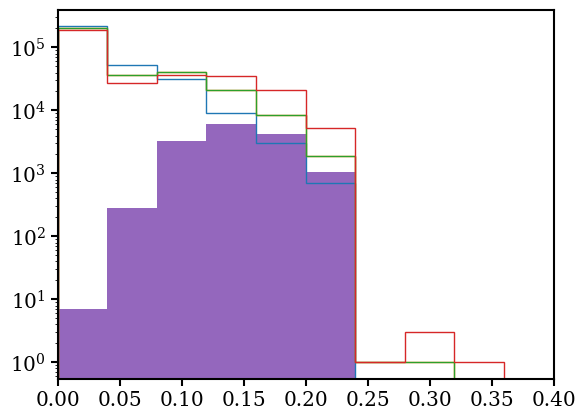

In [28]:
plt.hist(1/np.sqrt(color_cat["ABSMAG01_IVAR_SDSS_G"]),histtype="step",range=(0,0.4))
plt.hist(1/np.sqrt(color_cat["ABSMAG01_IVAR_SDSS_R"]),histtype="step",range=(0,0.4))
plt.hist(1/np.sqrt(color_cat["ABSMAG01_IVAR_SDSS_R"]),histtype="step",range=(0,0.4))
plt.hist(1/np.sqrt(color_cat["ABSMAG01_IVAR_SDSS_Z"]),histtype="step",range=(0,0.4))
plt.hist(1/np.sqrt(color_cat["ABSMAG01_IVAR_SDSS_Z"][zred_mask]),histtype="stepfilled",range=(0,0.4))
plt.xlim([0,0.4])
plt.yscale("log")
plt.show()



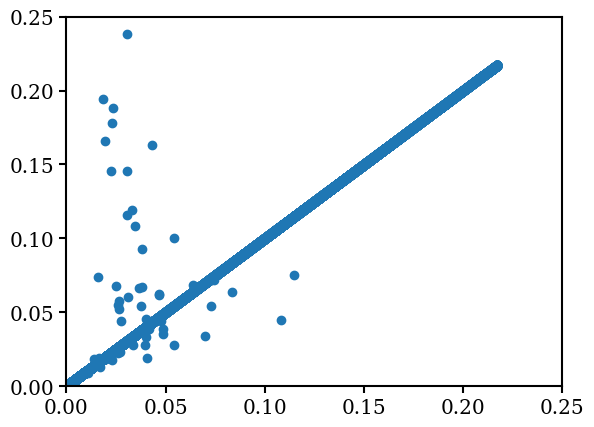

In [76]:
## how does the error here compare with error in photoemtry

# Magnitude error: dm = 1.086 * (df / f)
mag_err_z = 1.086 * np.sqrt(1/color_cat["FLUX_IVAR_Z"]) / color_cat["FLUX_Z"]

plt.scatter(mag_err_z, 1/np.sqrt(color_cat["ABSMAG01_IVAR_SDSS_Z"]) ) 
plt.xlim([0,0.25])
plt.ylim([0,0.25])
plt.show()

##so the error in the kcorrected magnitude is the same as the error in the observed photometry ... 

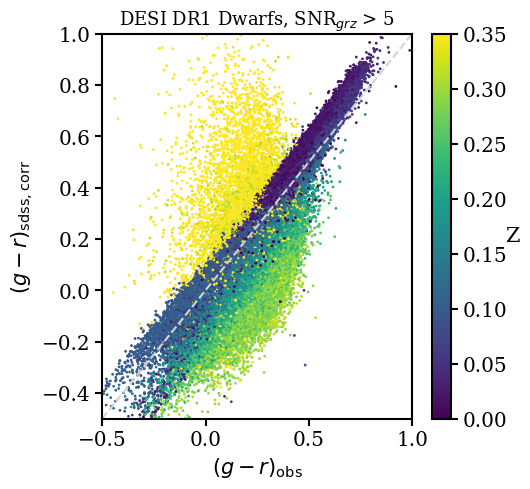

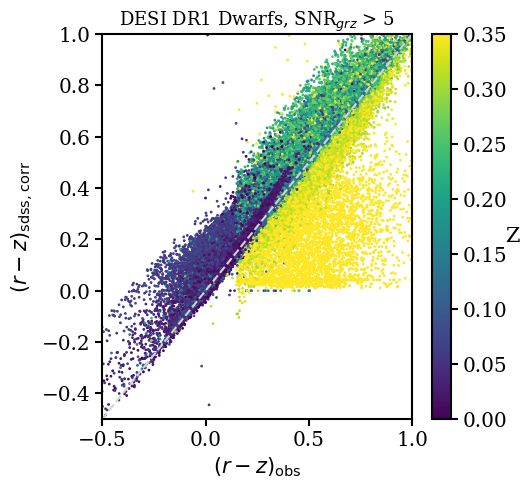

In [29]:
plt.figure(figsize = (5,5))
plt.title(r"DESI DR1 Dwarfs, SNR$_{grz}$ > 5",fontsize = 13)
plt.scatter(gr_obs[snr_mask], gr_sdss_corr[snr_mask],s=1,alpha=1,c=zred[snr_mask],vmin=0,vmax=0.35)
cbar = plt.colorbar()
cbar.set_label("Z", rotation=0, fontsize=15)
plt.plot([-0.5,1],[-0.5,1],color="lightgrey",ls="--")
plt.xlabel(r"$(g-r)_{\rm obs}$",fontsize = 15)
plt.ylabel(r"$(g-r)_{\rm sdss,corr}$",fontsize = 15)
plt.xlim([-0.5,1])
plt.ylim([-0.5,1])
plt.show()

plt.figure(figsize = (5,5))
plt.title(r"DESI DR1 Dwarfs, SNR$_{grz}$ > 5",fontsize = 13)
plt.scatter(rz_obs[snr_mask], rz_sdss_corr[snr_mask],s=1,alpha=1,c=zred[snr_mask],vmin=0,vmax=0.35)
cbar = plt.colorbar()
cbar.set_label("Z", rotation=0, fontsize=15)
plt.plot([-0.5,1],[-0.5,1],color="lightgrey",ls="--")
plt.xlabel(r"$(r-z)_{\rm obs}$",fontsize = 15)
plt.ylabel(r"$(r-z)_{\rm sdss,corr}$",fontsize = 15)
plt.xlim([-0.5,1])
plt.ylim([-0.5,1])
plt.show()

This makes sense, the constant-ish offset is probably due to filter difference between sdss and decam, and that sdss corr colors are at 0.1 while decam is observed colors.

Furthermore, the largest offset points are indeed the highest redshift galaxies

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


def weighted_cov_ellipse(gr, rz, ivars_gr, ivars_rz):
    """
    Compute weighted covariance matrix for (g-r, r-z) colors
    and return ellipse parameters (width, height, angle).
    
    Since g-r and r-z share the r-band, they are correlated.
    """
    # Use geometric mean of ivars as weights (or just one of them)
    # More sophisticated: use minimum or harmonic mean
    weights = np.sqrt(ivars_gr * ivars_rz)
    
    valid = (np.isfinite(gr) & np.isfinite(rz) & 
             np.isfinite(weights) & (weights > 0))
    
    if np.sum(valid) < 3:
        return np.nan, np.nan, 0.0
    
    gr_v = gr[valid]
    rz_v = rz[valid]
    w = weights[valid]
    
    # Normalize weights
    w_norm = w / np.sum(w)
    
    # Weighted means
    gr_mean = np.sum(w_norm * gr_v)
    rz_mean = np.sum(w_norm * rz_v)
    
    # Weighted covariance matrix
    # Using reliability weights correction factor
    V1 = np.sum(w)
    V2 = np.sum(w**2)
    correction = V1 / (V1 - V2/V1)
    
    cov_gr_gr = correction * np.sum(w_norm * (gr_v - gr_mean)**2)
    cov_rz_rz = correction * np.sum(w_norm * (rz_v - rz_mean)**2)
    cov_gr_rz = correction * np.sum(w_norm * (gr_v - gr_mean) * (rz_v - rz_mean))
    
    cov_matrix = np.array([[cov_gr_gr, cov_gr_rz],
                           [cov_gr_rz, cov_rz_rz]])
    
    # Eigenvalue decomposition for ellipse
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # Sort by eigenvalue (largest first)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    # Ellipse parameters (1-sigma)
    width = 2 * np.sqrt(eigenvalues[0])   # major axis
    height = 2 * np.sqrt(eigenvalues[1])  # minor axis
    
    # Angle of major axis (in degrees)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    
    return width, height, angle


def weighted_average(values, ivars):
    """Inverse variance weighted average."""
    valid = np.isfinite(values) & np.isfinite(ivars) & (ivars > 0)
    if np.sum(valid) == 0:
        return np.nan, np.nan
    w = ivars[valid]
    v = values[valid]
    avg = np.sum(w * v) / np.sum(w)
    err = 1.0 / np.sqrt(np.sum(w))
    return avg, err


zred_bins = np.arange(0.025, 0.35, 0.025)
# zred_bins = np.concatenate( [ np.arange(0.01, 0.15, 0.05) , np.arange(0.15, 0.4,0.1) ] )

zred_cens = 0.5 * (zred_bins[:-1] + zred_bins[1:])

# Containers for colors
gr_elg, rz_elg = [], []
gr_noelg, rz_noelg = [], []
gr_obs_elg, rz_obs_elg = [], []
gr_obs_noelg, rz_obs_noelg = [], []

# Containers for ellipse parameters (width, height, angle)
ellipse_elg, ellipse_noelg = [], []
ellipse_obs_elg, ellipse_obs_noelg = [], []

for i in range(len(zred_bins) - 1):
    z_min = zred_bins[i]
    z_max = zred_bins[i + 1]
    
    elg_sub_cat = select_sample(tot_cat, "ELG", z_min=z_min, z_max=z_max)
    noelg_sub_cat = select_sample(tot_cat, "BGS_BRIGHT", z_min=z_min, z_max=z_max)
    
    # ----------------------------
    # ELGs
    # ----------------------------
    if len(elg_sub_cat) > 25:
        # Observed colors
        gr_obs = elg_sub_cat["MAG_G"].data - elg_sub_cat["MAG_R"].data
        rz_obs = elg_sub_cat["MAG_R"].data - elg_sub_cat["MAG_Z"].data
        
        g_ivar = elg_sub_cat["FLUX_IVAR_G"].data * elg_sub_cat["FLUX_G"].data**2 / 1.086**2
        r_ivar = elg_sub_cat["FLUX_IVAR_R"].data * elg_sub_cat["FLUX_R"].data**2 / 1.086**2
        z_ivar = elg_sub_cat["FLUX_IVAR_Z"].data * elg_sub_cat["FLUX_Z"].data**2 / 1.086**2
        
        gr_obs_ivar = 1.0 / (1.0/g_ivar + 1.0/r_ivar)
        rz_obs_ivar = 1.0 / (1.0/r_ivar + 1.0/z_ivar)
        
        # K-corrected colors
        gr_corr = elg_sub_cat["ABSMAG01_SDSS_G"].data - elg_sub_cat["ABSMAG01_SDSS_R"].data
        rz_corr = elg_sub_cat["ABSMAG01_SDSS_R"].data - elg_sub_cat["ABSMAG01_SDSS_Z"].data

        g_corr_ivar = elg_sub_cat["ABSMAG01_IVAR_SDSS_G"].data
        r_corr_ivar = elg_sub_cat["ABSMAG01_IVAR_SDSS_R"].data
        z_corr_ivar = elg_sub_cat["ABSMAG01_IVAR_SDSS_Z"].data
        
        gr_corr_ivar = 1.0 / (1.0/g_corr_ivar + 1.0/r_corr_ivar)
        rz_corr_ivar = 1.0 / (1.0/r_corr_ivar + 1.0/z_corr_ivar)
        
        # Weighted means
        val, _ = weighted_average(gr_corr, gr_corr_ivar)
        gr_elg.append(val)
        val, _ = weighted_average(rz_corr, rz_corr_ivar)
        rz_elg.append(val)
        
        val, _ = weighted_average(gr_obs, gr_obs_ivar)
        gr_obs_elg.append(val)
        val, _ = weighted_average(rz_obs, rz_obs_ivar)
        rz_obs_elg.append(val)
        
        # Ellipse parameters (with covariance)
        ellipse_elg.append(weighted_cov_ellipse(gr_corr, rz_corr, gr_corr_ivar, rz_corr_ivar))
        ellipse_obs_elg.append(weighted_cov_ellipse(gr_obs, rz_obs, gr_obs_ivar, rz_obs_ivar))
    else:
        gr_elg.append(np.nan)
        rz_elg.append(np.nan)
        gr_obs_elg.append(np.nan)
        rz_obs_elg.append(np.nan)
        ellipse_elg.append((np.nan, np.nan, 0.0))
        ellipse_obs_elg.append((np.nan, np.nan, 0.0))
    
    # ----------------------------
    # Non-ELGs
    # ----------------------------
    if len(noelg_sub_cat) > 25:
        gr_obs = noelg_sub_cat["MAG_G"].data - noelg_sub_cat["MAG_R"].data
        rz_obs = noelg_sub_cat["MAG_R"].data - noelg_sub_cat["MAG_Z"].data
        
        g_ivar = noelg_sub_cat["FLUX_IVAR_G"].data * noelg_sub_cat["FLUX_G"].data**2 / 1.086**2
        r_ivar = noelg_sub_cat["FLUX_IVAR_R"].data * noelg_sub_cat["FLUX_R"].data**2 / 1.086**2
        z_ivar = noelg_sub_cat["FLUX_IVAR_Z"].data * noelg_sub_cat["FLUX_Z"].data**2 / 1.086**2
        
        gr_obs_ivar = 1.0 / (1.0/g_ivar + 1.0/r_ivar)
        rz_obs_ivar = 1.0 / (1.0/r_ivar + 1.0/z_ivar)
        
        gr_corr = noelg_sub_cat["ABSMAG01_SDSS_G"].data - noelg_sub_cat["ABSMAG01_SDSS_R"].data
        rz_corr = noelg_sub_cat["ABSMAG01_SDSS_R"].data - noelg_sub_cat["ABSMAG01_SDSS_Z"].data
        
        g_corr_ivar = noelg_sub_cat["ABSMAG01_IVAR_SDSS_G"].data
        r_corr_ivar = noelg_sub_cat["ABSMAG01_IVAR_SDSS_R"].data
        z_corr_ivar = noelg_sub_cat["ABSMAG01_IVAR_SDSS_Z"].data
        
        gr_corr_ivar = 1.0 / (1.0/g_corr_ivar + 1.0/r_corr_ivar)
        rz_corr_ivar = 1.0 / (1.0/r_corr_ivar + 1.0/z_corr_ivar)
        
        val, _ = weighted_average(gr_corr, gr_corr_ivar)
        gr_noelg.append(val)
        val, _ = weighted_average(rz_corr, rz_corr_ivar)
        rz_noelg.append(val)
        
        val, _ = weighted_average(gr_obs, gr_obs_ivar)
        gr_obs_noelg.append(val)
        val, _ = weighted_average(rz_obs, rz_obs_ivar)
        rz_obs_noelg.append(val)
        
        ellipse_noelg.append(weighted_cov_ellipse(gr_corr, rz_corr, gr_corr_ivar, rz_corr_ivar))
        ellipse_obs_noelg.append(weighted_cov_ellipse(gr_obs, rz_obs, gr_obs_ivar, rz_obs_ivar))
    else:
        gr_noelg.append(np.nan)
        rz_noelg.append(np.nan)
        gr_obs_noelg.append(np.nan)
        rz_obs_noelg.append(np.nan)
        ellipse_noelg.append((np.nan, np.nan, 0.0))
        ellipse_obs_noelg.append((np.nan, np.nan, 0.0))

# Convert to arrays
gr_elg, rz_elg = np.array(gr_elg), np.array(rz_elg)
gr_noelg, rz_noelg = np.array(gr_noelg), np.array(rz_noelg)
gr_obs_elg, rz_obs_elg = np.array(gr_obs_elg), np.array(rz_obs_elg)
gr_obs_noelg, rz_obs_noelg = np.array(gr_obs_noelg), np.array(rz_obs_noelg)




Total number selected = 1568
Total number selected = 50466
Total number selected = 4880
Total number selected = 37871
Total number selected = 17463
Total number selected = 9180
Total number selected = 23322
Total number selected = 362
Total number selected = 16615
Total number selected = 4
Total number selected = 10633
Total number selected = 0
Total number selected = 10213
Total number selected = 0
Total number selected = 10222
Total number selected = 0
Total number selected = 8888
Total number selected = 0
Total number selected = 7632
Total number selected = 0
Total number selected = 6262
Total number selected = 0
Total number selected = 5624
Total number selected = 0


In [8]:
len(zred_bins)

13

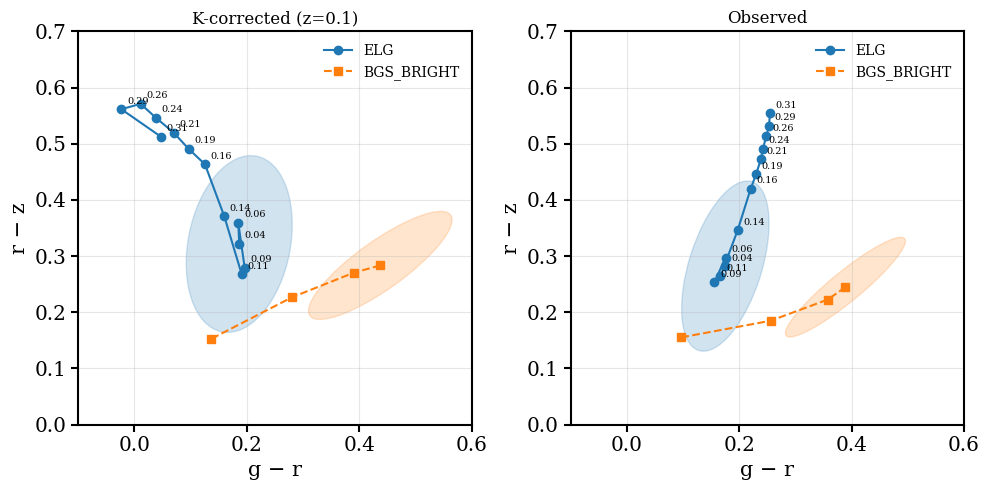

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# =============================================================================
# Plotting with proper covariance ellipses (only for selected bins)
# =============================================================================

# Indices of redshift bins to plot ellipses for
ellipse_bins = [0]  # adjust as needed

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Left panel: K-corrected colors
ax[0].plot(gr_elg, rz_elg, marker="o", label="ELG", zorder=3)
ax[0].plot(gr_noelg, rz_noelg, marker="s", linestyle="--", label="BGS_BRIGHT", zorder=3)

for i in ellipse_bins:
    w, h, angle = ellipse_elg[i]
    if np.isfinite(w):
        ellipse = Ellipse((gr_elg[i], rz_elg[i]), width=w, height=h, angle=angle,
                          alpha=0.2, color='C0', zorder=1)
        ax[0].add_patch(ellipse)
    
    w, h, angle = ellipse_noelg[i]
    if np.isfinite(w):
        ellipse = Ellipse((gr_noelg[i], rz_noelg[i]), width=w, height=h, angle=angle,
                          alpha=0.2, color='C1', zorder=1)
        ax[0].add_patch(ellipse)

for i, z in enumerate(zred_cens):
    if np.isfinite(gr_elg[i]):
        ax[0].text(gr_elg[i]+0.01, rz_elg[i]+0.01, f"{z:.2f}", fontsize=7)

ax[0].set_xlabel("g − r", fontsize=15)
ax[0].set_ylabel("r − z", fontsize=15)
ax[0].set_title("K-corrected (z=0.1)", fontsize=12)
ax[0].legend()
ax[0].grid(alpha=0.3)

# Right panel: Observed colors
ax[1].plot(gr_obs_elg, rz_obs_elg, marker="o", label="ELG", zorder=3)
ax[1].plot(gr_obs_noelg, rz_obs_noelg, marker="s", linestyle="--", label="BGS_BRIGHT", zorder=3)

for i in ellipse_bins:
    w, h, angle = ellipse_obs_elg[i]
    if np.isfinite(w):
        ellipse = Ellipse((gr_obs_elg[i], rz_obs_elg[i]), width=w, height=h, angle=angle,
                          alpha=0.2, color='C0', zorder=1)
        ax[1].add_patch(ellipse)
    
    w, h, angle = ellipse_obs_noelg[i]
    if np.isfinite(w):
        ellipse = Ellipse((gr_obs_noelg[i], rz_obs_noelg[i]), width=w, height=h, angle=angle,
                          alpha=0.2, color='C1', zorder=1)
        ax[1].add_patch(ellipse)

for i, z in enumerate(zred_cens):
    if np.isfinite(gr_obs_elg[i]):
        ax[1].text(gr_obs_elg[i]+0.01, rz_obs_elg[i]+0.01, f"{z:.2f}", fontsize=7)

ax[1].set_xlabel("g − r", fontsize=15)
ax[1].set_ylabel("r − z", fontsize=15)
ax[1].set_title("Observed", fontsize=12)
ax[1].legend()
ax[1].grid(alpha=0.3)

for axi in ax:
    axi.set_xlim([-0.1, 0.6])
    axi.set_ylim([0.0, 0.7])
    axi.set_aspect('equal')

plt.tight_layout()
plt.show()



Figure X shows the color tracks of ELG and BGS_BRIGHT samples in g−r vs. r−z color space as a function of redshift. The left panel shows rest-frame colors K-corrected to z=0.1 using the ABSMAG01_SDSS columns, while the right panel shows observed colors. Points are labeled by the central redshift of each bin (Δz = 0.025).
For each redshift bin, we compute the inverse-variance weighted mean color, where the weight for each galaxy is derived from the photometric flux uncertainties (e.g., for g−r: w = 1/(σ_g² + σ_r²)). The ellipses show the 1σ intrinsic population scatter, computed from the weighted covariance matrix of the two colors. The ellipse orientation and axis ratio are determined by eigenvalue decomposition of the 2×2 covariance matrix. The positive tilt of the ellipses reflects the astrophysical correlation between g−r and r−z: redder galaxies tend to be red in both colors due to shared dependence on dust, age, and metallicity.

In [139]:
elg_sub_cat_i = select_sample(tot_cat, "ELG", z_min=0.025, z_max=0.05)
noelg_sub_cat_i = select_sample(tot_cat, "BGS_BRIGHT", z_min=0.025, z_max=0.05)

# gr_obs = elg_sub_cat_i["MAG_G"].data - elg_sub_cat_i["MAG_R"].data
# rz_obs = elg_sub_cat_i["MAG_R"].data - elg_sub_cat_i["MAG_Z"].data

gr_obs = noelg_sub_cat_i["MAG_G"].data - noelg_sub_cat_i["MAG_R"].data
rz_obs = noelg_sub_cat_i["MAG_R"].data - noelg_sub_cat_i["MAG_Z"].data


Total number selected = 1568
Total number selected = 50466


In [140]:
corr = np.corrcoef(gr_obs, rz_obs)[0, 1]
print(f"Correlation coefficient: {corr:.2f}")

Correlation coefficient: 0.87


In [10]:
from desi_lowz_funcs import plot_2d_dist
from catalog_paper_plots import make_cmap



In [11]:
tot_cat_no_elg = tot_cat[tot_cat["SAMPLE"] != "ELG"]
print(len(tot_cat_no_elg))

191297


In [12]:
len(ellipse_elg), len(zred_cens)

(12, 12)

In [13]:
zred_cens

array([0.0375, 0.0625, 0.0875, 0.1125, 0.1375, 0.1625, 0.1875, 0.2125,
       0.2375, 0.2625, 0.2875, 0.3125])

In [14]:
# tot_cat_no_elg["g-r"] =tot_cat_no_elg["ABSMAG01_SDSS_G"] - tot_cat_no_elg["ABSMAG01_SDSS_R"] 
# tot_cat_no_elg["r-z"] =tot_cat_no_elg["ABSMAG01_SDSS_R"] - tot_cat_no_elg["ABSMAG01_SDSS_Z"] 

tot_cat_no_elg["g-r"] =tot_cat_no_elg["MAG_G"] - tot_cat_no_elg["MAG_R"] 
tot_cat_no_elg["r-z"] =tot_cat_no_elg["MAG_R"] - tot_cat_no_elg["MAG_Z"] 


In [75]:

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cmasher as cmr

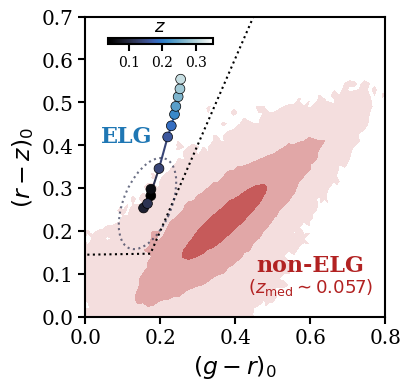

In [91]:
fig,ax = make_subplots(ncol = 1, nrow = 1, return_fig=True)

# norm = mcolors.Normalize(vmin=zred_cens.min(), vmax=zred_cens.max())
norm = mcolors.Normalize(vmin=zred_cens.min(), vmax=0.35)
# norm = mcolors.Normalize(vmin=0.0375, vmax=0.4)

cmap = cmr.arctic  # or viridis, coolwarm, etc.

# scatter points colored by redshift
sc = ax[0].scatter(gr_obs_elg, rz_obs_elg, c=zred_cens, cmap=cmap, norm=norm,
                   edgecolors='k', linewidths=0.5, s=50, zorder=3)

# optionally color the line segments too
for i in range(len(gr_elg)-1):
    ax[0].plot(gr_obs_elg[i:i+2], rz_obs_elg[i:i+2],
               color=cmap(norm(zred_cens[i])), zorder=2)

# inset colorbar
cbax = ax[0].inset_axes([0.075, 0.91, 0.35, 0.02])  # wide & short for horizontal
cbar = plt.colorbar(sc, cax=cbax, orientation='horizontal')
cbar.set_label(r"$z$", fontsize=13, labelpad=5)  # negative pad puts label on top
cbar.ax.tick_params(labelsize=10, bottom=True, top=False)
cbar.ax.set_xticks([0.1,0.2,0.3])
cbar.ax.xaxis.set_label_position('top')

####


ellipse_bins = [3]

for i in ellipse_bins:
    w, h, angle = ellipse_obs_elg[i]
    if np.isfinite(w):
        ellipse = Ellipse((gr_obs_elg[i], rz_obs_elg[i]), width=w, height=h, angle=angle,
                  facecolor='none', edgecolor=cmap(norm(zred_cens[i])), linewidth=1.5, zorder=5, ls="dotted", alpha=0.7)
        ax[0].add_patch(ellipse)
    

nonelg_color = "firebrick"

plot_2d_dist(tot_cat_no_elg["g-r"], tot_cat_no_elg["r-z"], 150, 150, 
                cmin=1.e-4, cmax=1.0, smooth=None, clevs=[0,0.393,0.865,0.989],ax=ax[0], bounds= np.array([ -1,1,-1,1]),
            cmap = make_cmap("firebrick"), color = nonelg_color, filled=True, cmap_alpha=1)

start = 0.175

ax[0].text(0.14,0.6,"ELG",color = "tab:blue", transform=ax[0].transAxes, weight="bold",fontsize = 16,ha="center",va="center",alpha=1 )

ax[0].text(0.75,0.17,"non-ELG",color = nonelg_color, transform=ax[0].transAxes, weight="bold",fontsize = 16,ha="center",va="center" )

zred_med_noelg = np.median(tot_cat_no_elg["Z"])

ax[0].text(0.75,0.1,rf"$(z_{{\rm med}} \sim {zred_med_noelg:.3f})$",color = nonelg_color, transform=ax[0].transAxes, weight="bold",fontsize = 13,ha="center",va="center" )


ax[0].set_xlim([0,0.8])
ax[0].set_ylim([0,0.7])

ax[0].set_xlabel(r"$(g-r)_{0}$",fontsize=17)
ax[0].set_ylabel(r"$(r-z)_{0}$",fontsize=17)

# ax[0].set_xticks([0,0.25,0.5,0.75])
# ax[0].set_yticks([0,0.25,0.5,0.75])

###plot the ELG color selection:

gr_elg_box = [-0.5039115756670784, 0.17415113938843074, 0.5343050055184053, -0.5072323573329873 ]
rz_elg_box = [0.13744075829383862, 0.14691943127962093, 0.8720379146919433, 1.753554502369668 ]

ax[0].plot(gr_elg_box, rz_elg_box,color="k",ls="dotted")

# from matplotlib.patches import Polygon

# # Define vertices that enclose the region above/left of the color box
# # Go along the box boundary, then extend to the plot corners
# shade_verts = [
#     (gr_elg_box[0], rz_elg_box[0]),  # bottom-left of box
#     (gr_elg_box[1], rz_elg_box[1]),  # bottom-right of box
#     (gr_elg_box[2], rz_elg_box[2]),  # top-right of box
#     (gr_elg_box[3], rz_elg_box[3]),  # top-left of box
#     # now extend to plot corners (upper-left region)
#     (ax[0].get_xlim()[0], ax[0].get_ylim()[1]),  # top-left corner
#     (ax[0].get_xlim()[0], rz_elg_box[0]),         # back to left edge at box height
# ]

# shade = Polygon(shade_verts, closed=True, facecolor='dodgerblue', alpha=0.15, edgecolor='none', zorder=0)
# ax[0].add_patch(shade)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarfs_gr_rz_plot.pdf",bbox_inches="tight")

plt.show()

In [92]:

shorten = -1
cont_width=10
LINE_WINDOWS = {
    "Halpha": (6558.0 - shorten, 6571.0 + shorten,5),
    "NII_6548": (6545.0 + 1, 6555.0 - 1, 5),
    "NII_6583": (6578.0 + 2, 6592.0 - 2,cont_width),
    "Hbeta": (4848.0 + 10, 4878.0 - 10, 3),
    "OIII_4959": (4945.0 + 10, 4975.0 - 10,5),
    "OIII_5007": (4990.0 + 10, 5025.0 - 10,5),
    "OII": (3710.0 + 12, 3750.0 - 14,5),
    "SII": (6700.0 + 12, 6755.0 - 16 , 5),
}


In [93]:
zred_bins = np.concatenate( [ np.arange(0.01, 0.15, 0.01) , np.arange(0.15, 0.35,0.05) ] )

zcens = 0.5 * (zred_bins[1:] + zred_bins[:-1])

from elg_explore import measure_all_lines_boxcar, compute_line_ratios_bootstrap

In [94]:
zred_bins

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.2 , 0.25, 0.3 ])

Total number selected = 68
Total number selected = 7389
Loading existing NO-ELG stack for z=[0.010, 0.020]


/tmp/ipykernel_1170682/1251796049.py:122: RuntimeWarning: All-NaN slice encountered
  axi.set_ylim([0, np.nanmax(stack_spec_elg) * 1.1])


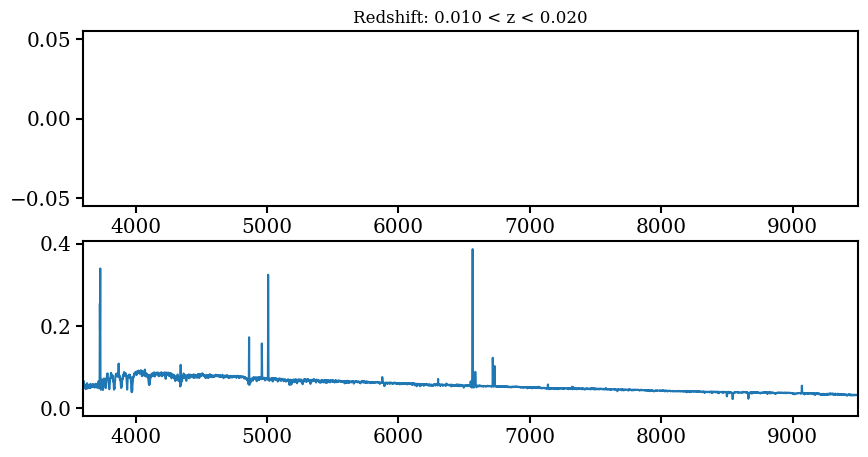

--
Total number selected = 241
Total number selected = 17963
Loading existing NO-ELG stack for z=[0.020, 0.030]


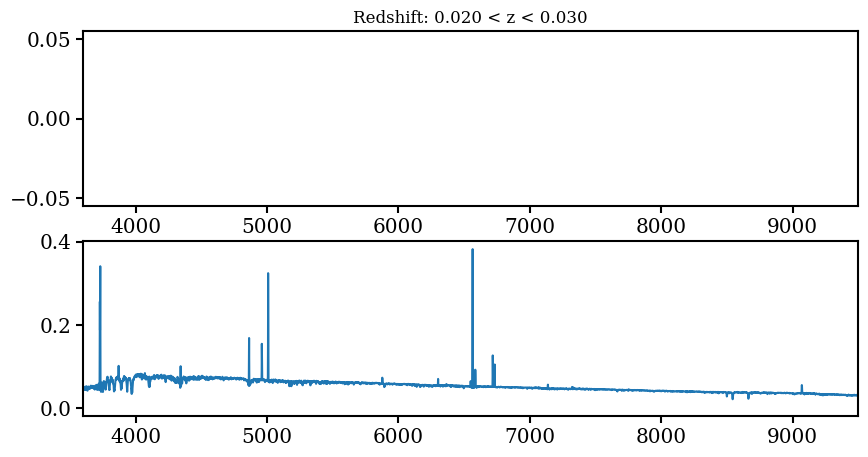

--
Total number selected = 535
Total number selected = 25628
Loading existing ELG stack for z=[0.030, 0.040]
Loading existing NO-ELG stack for z=[0.030, 0.040]


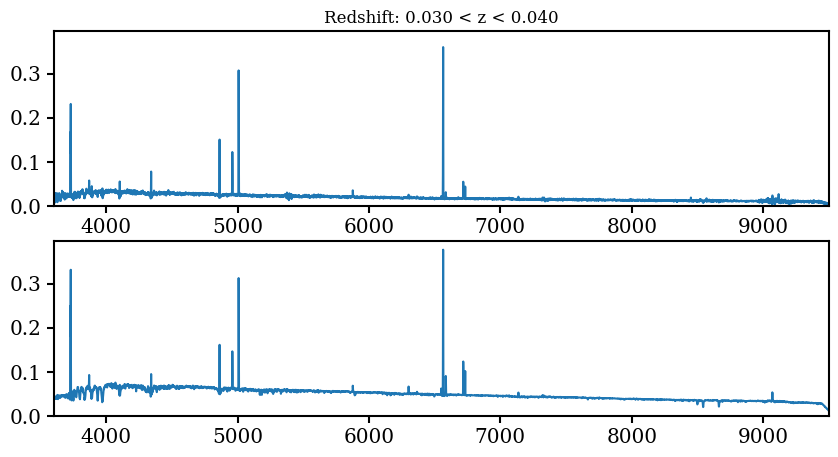

--
Total number selected = 888
Total number selected = 25113
Loading existing ELG stack for z=[0.040, 0.050]
Loading existing NO-ELG stack for z=[0.040, 0.050]


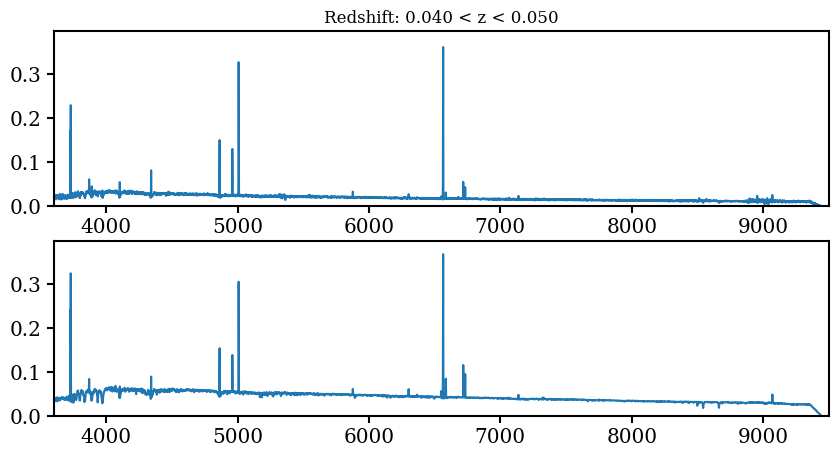

--
Total number selected = 1273
Total number selected = 25300
Loading existing ELG stack for z=[0.050, 0.060]
Loading existing NO-ELG stack for z=[0.050, 0.060]


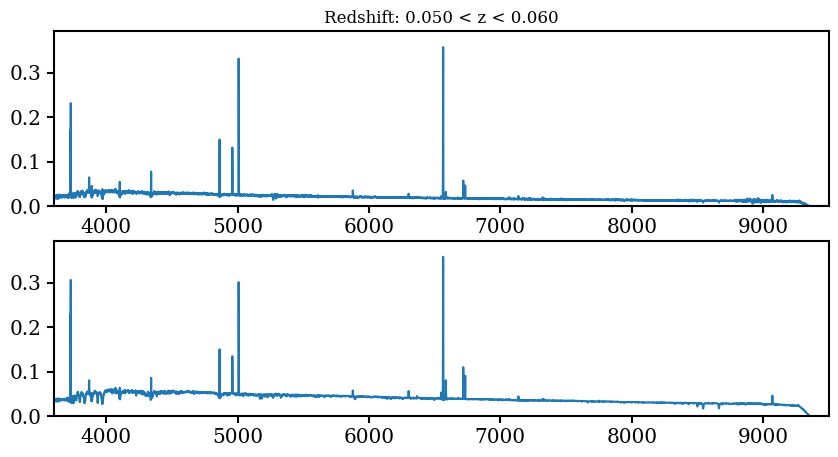

--
Total number selected = 2055
Total number selected = 23901
Loading existing ELG stack for z=[0.060, 0.070]
Loading existing NO-ELG stack for z=[0.060, 0.070]


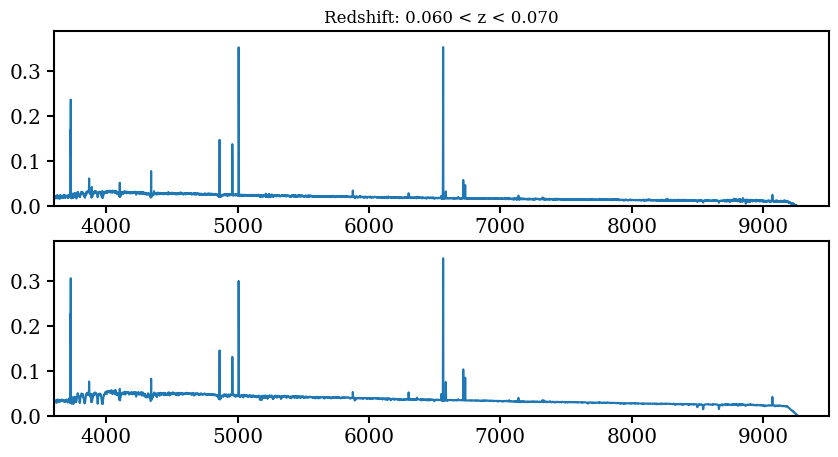

--
Total number selected = 3576
Total number selected = 20737
Loading existing ELG stack for z=[0.070, 0.080]
Loading existing NO-ELG stack for z=[0.070, 0.080]


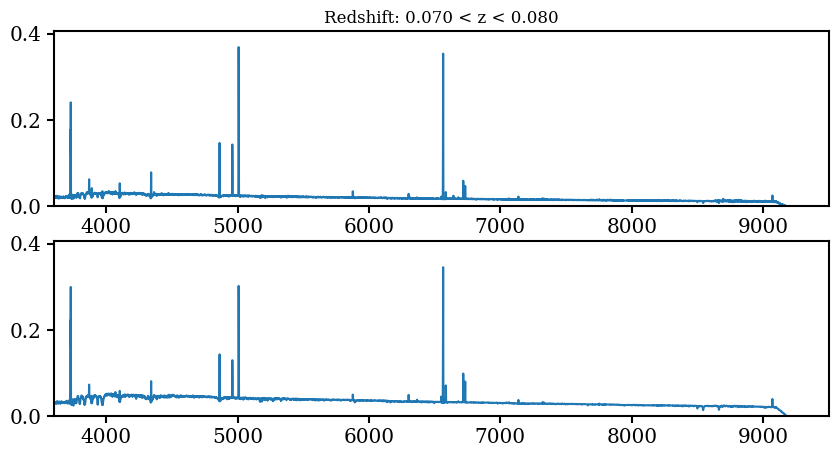

--
Total number selected = 5679
Total number selected = 16743
Loading existing ELG stack for z=[0.080, 0.090]
Loading existing NO-ELG stack for z=[0.080, 0.090]


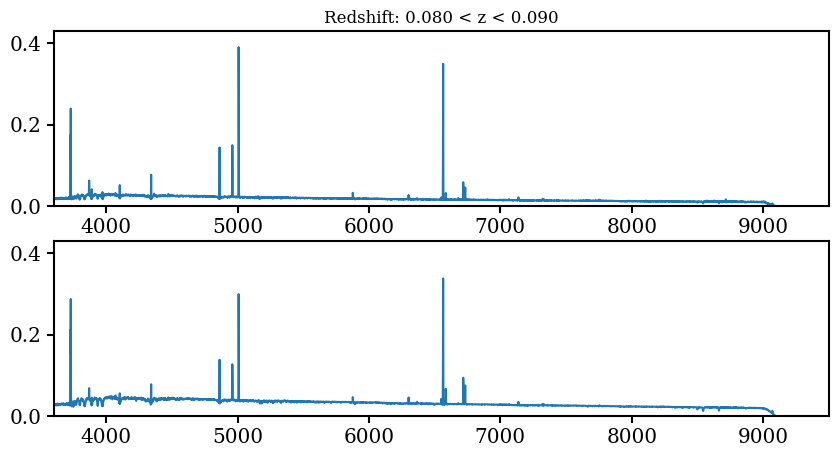

--
Total number selected = 9760
Total number selected = 10851
Loading existing ELG stack for z=[0.090, 0.100]
Loading existing NO-ELG stack for z=[0.090, 0.100]


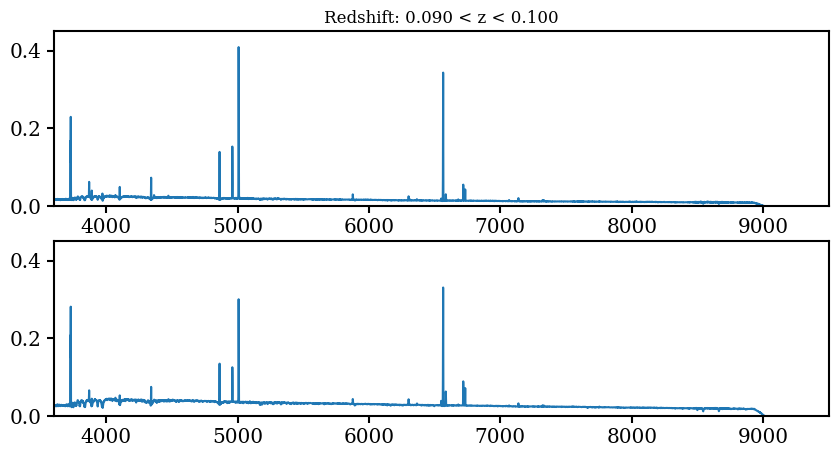

--
Total number selected = 9186
Total number selected = 6696
Loading existing ELG stack for z=[0.100, 0.110]
Loading existing NO-ELG stack for z=[0.100, 0.110]


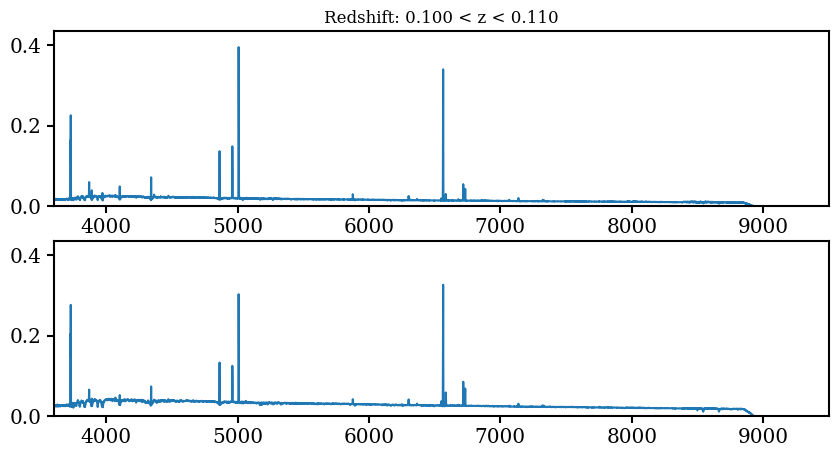

--
Total number selected = 9111
Total number selected = 4240
Loading existing ELG stack for z=[0.110, 0.120]
Loading existing NO-ELG stack for z=[0.110, 0.120]


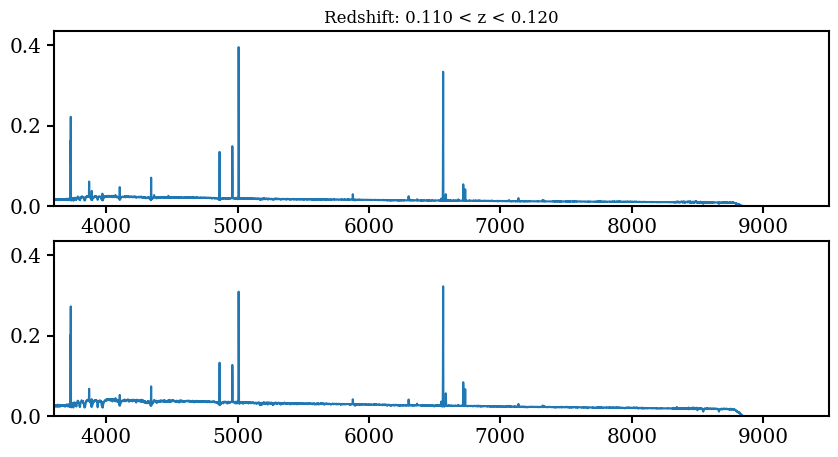

--
Total number selected = 9574
Total number selected = 2824
Loading existing ELG stack for z=[0.120, 0.130]
Loading existing NO-ELG stack for z=[0.120, 0.130]


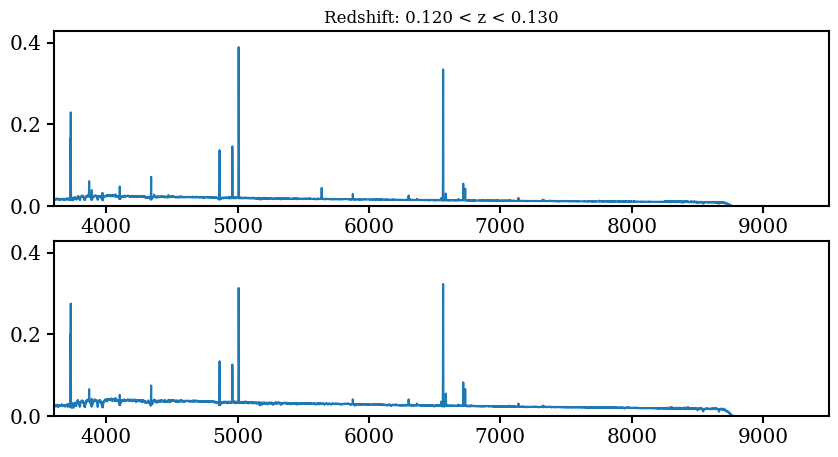

--
Total number selected = 6812
Total number selected = 1384
Loading existing ELG stack for z=[0.130, 0.140]
Loading existing NO-ELG stack for z=[0.130, 0.140]


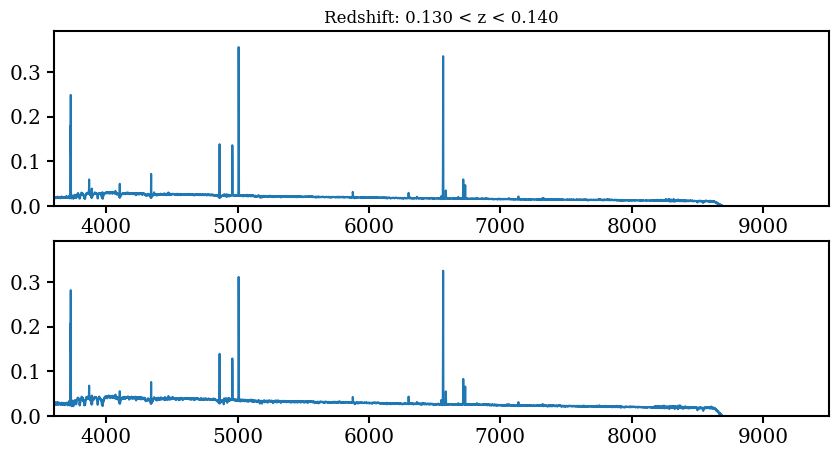

--
Total number selected = 5254
Total number selected = 619
Loading existing ELG stack for z=[0.140, 0.150]
Loading existing NO-ELG stack for z=[0.140, 0.150]


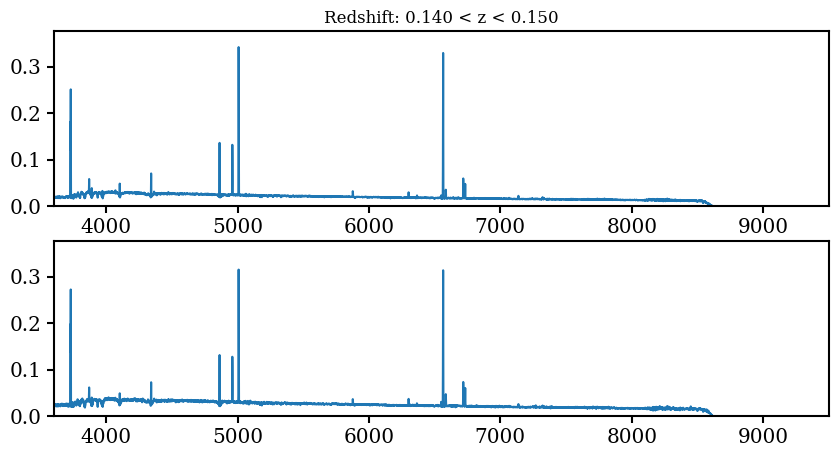

--
Total number selected = 20846
Total number selected = 330
Loading existing ELG stack for z=[0.150, 0.200]


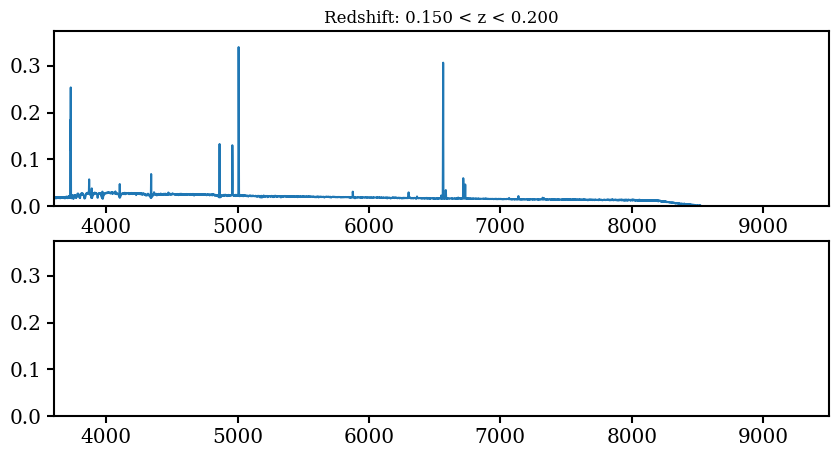

--
Total number selected = 19110
Total number selected = 0
Loading existing ELG stack for z=[0.200, 0.250]


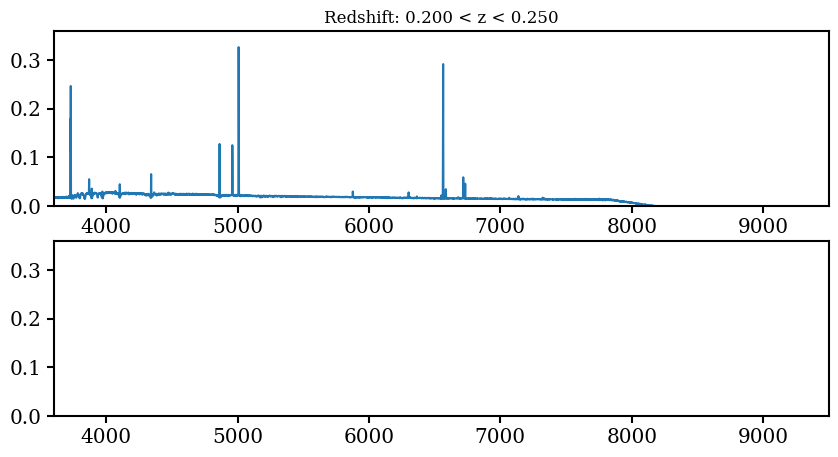

--
Total number selected = 13894
Total number selected = 0
Loading existing ELG stack for z=[0.250, 0.300]


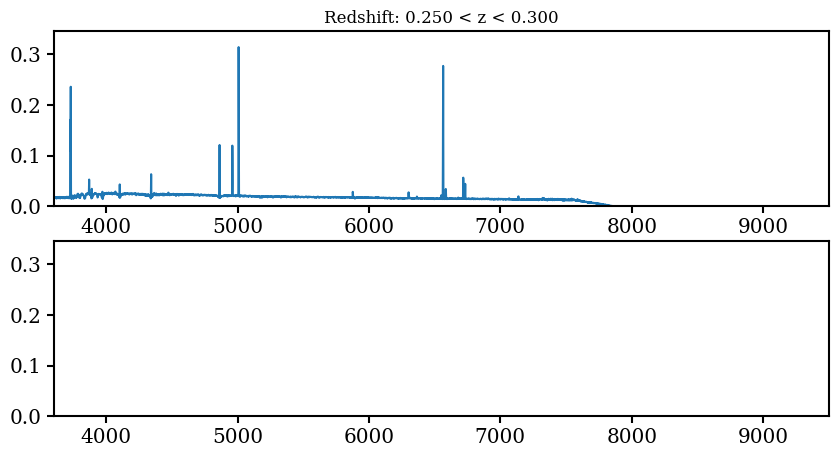

--


In [105]:
# =============================================================================
# Main loop
# =============================================================================
import pickle
from astropy.io import fits

stack_spec_elg_dict = {}
stack_spec_noelg_dict = {}
line_ratios_elg_dict = {}
line_ratios_noelg_dict = {}
overwrite = False
stack_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/zred/"

# Create directory if it doesn't exist
os.makedirs(stack_path, exist_ok=True)

for i in range(len(zred_bins) - 1):
    zmin_i = zred_bins[i]
    zmax_i = zred_bins[i + 1]
    
    elg_sub_cat_i = select_sample(tot_cat, "ELG", z_min=zmin_i, z_max=zmax_i)
    noelg_sub_cat_i = select_sample(tot_cat, "NO_ELG", z_min=zmin_i, z_max=zmax_i)
    
    stack_nlim = 500
    
    # ----------------------------
    # ELG stack
    # ----------------------------
    if len(elg_sub_cat_i) > stack_nlim:
        stack_file_elg = stack_path + f"stacks_spec_elg_{zmin_i:.3f}_{zmax_i:.3f}.pkl"
        
        if os.path.exists(stack_file_elg) and overwrite == False:
            print(f"Loading existing ELG stack for z=[{zmin_i:.3f}, {zmax_i:.3f}]")
            with open(stack_file_elg, 'rb') as f:
                saved_data = pickle.load(f)
                stack_spec_elg = saved_data['stack_spec']
                stack_err_elg = saved_data['stack_err']
                all_stacks_elg = saved_data['all_stacks']
        else:
            print(f"Computing ELG stack for z=[{zmin_i:.3f}, {zmax_i:.3f}]")
            flux_elg_i, ivar_elg_i, haf_elg_i, tgids_elg_i = get_sample_spectra_with_halpha(
                elg_sub_cat_i, spectra_data
            )
            stack_spec_elg, stack_err_elg, all_stacks_elg = bootstrap_stack_fast_capped(
                flux_elg_i, ivar_elg_i, haf_elg_i, wave, random_seed=42
            )
            
            # Save the stacked spectra
            save_data = {
                'stack_spec': stack_spec_elg,
                'stack_err': stack_err_elg,
                'all_stacks': all_stacks_elg,
                'zmin': zmin_i,
                'zmax': zmax_i,
                'n_galaxies': len(elg_sub_cat_i)
            }
            with open(stack_file_elg, 'wb') as f:
                pickle.dump(save_data, f)
            print(f"Saved ELG stack to {stack_file_elg}")
            
        # Compute line ratios directly from bootstrap realizations
        line_ratios_elg_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_elg, LINE_WINDOWS
        )
    else:
        stack_spec_elg = np.full_like(wave, np.nan)
        line_ratios_elg_dict[i] = None
    
    # ----------------------------
    # NO-ELG stack
    # ----------------------------
    if len(noelg_sub_cat_i) > stack_nlim:
        stack_file_noelg = stack_path + f"stacks_spec_noelg_{zmin_i:.3f}_{zmax_i:.3f}.pkl"
        
        if os.path.exists(stack_file_noelg) and overwrite == False:
            print(f"Loading existing NO-ELG stack for z=[{zmin_i:.3f}, {zmax_i:.3f}]")
            with open(stack_file_noelg, 'rb') as f:
                saved_data = pickle.load(f)
                stack_spec_noelg = saved_data['stack_spec']
                stack_err_noelg = saved_data['stack_err']
                all_stacks_noelg = saved_data['all_stacks']
        else:
            print(f"Computing NO-ELG stack for z=[{zmin_i:.3f}, {zmax_i:.3f}]")
            flux_noelg_i, ivar_noelg_i, haf_noelg_i, tgids_noelg_i = get_sample_spectra_with_halpha(
                noelg_sub_cat_i, spectra_data
            )
            stack_spec_noelg, stack_err_noelg, all_stacks_noelg = bootstrap_stack_fast_capped(
                flux_noelg_i, ivar_noelg_i, haf_noelg_i, wave, random_seed=42
            )
            
            # Save the stacked spectra
            save_data = {
                'stack_spec': stack_spec_noelg,
                'stack_err': stack_err_noelg,
                'all_stacks': all_stacks_noelg,
                'zmin': zmin_i,
                'zmax': zmax_i,
                'n_galaxies': len(noelg_sub_cat_i)
            }
            with open(stack_file_noelg, 'wb') as f:
                pickle.dump(save_data, f)
            print(f"Saved NO-ELG stack to {stack_file_noelg}")
            
        line_ratios_noelg_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_noelg, LINE_WINDOWS
        )
    else:
        stack_spec_noelg = np.full_like(wave, np.nan)
        line_ratios_noelg_dict[i] = None
    
    # Plot stacked spectra
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    ax[0].set_title(f"Redshift: {zmin_i:.3f} < z < {zmax_i:.3f}")
    ax[0].plot(wave, stack_spec_elg, label="ELG")
    ax[1].plot(wave, stack_spec_noelg, label="BGS BRIGHT")

    for axi in ax:
        axi.set_xlim([3600, 9500])
        
    try:
        for axi in ax:
            axi.set_ylim([0, np.nanmax(stack_spec_elg) * 1.1])
    except:
        pass
        
    plt.show()
    
    stack_spec_elg_dict[i] = stack_spec_elg
    stack_spec_noelg_dict[i] = stack_spec_noelg
    print("--")

In [106]:
## we will save this stack

In [107]:
# =============================================================================
# Plotting line ratios with error bars
# =============================================================================

def ratio_with_error(a, a_err, b, b_err):
    """Compute ratio a/b and propagate errors."""
    ratio = a / b
    # Relative error propagation: (da/a)^2 + (db/b)^2
    rel_err = np.sqrt((a_err / a) ** 2 + (b_err / b) ** 2)
    return ratio, ratio * rel_err


def log_ratio_with_error(a, a_err, b, b_err):
    """Compute log10(a/b) and propagate errors."""
    ratio = a / b
    log_ratio = np.log10(ratio)
    # Error on log10(x) = 0.434 * dx/x
    rel_err = np.sqrt((a_err / a) ** 2 + (b_err / b) ** 2)
    log_err = 0.434 * rel_err
    return log_ratio, log_err


In [108]:
# =============================================================================
# Plotting line ratios with error bars
# =============================================================================

# Extract values and errors into arrays
ratio_names = ["halpha_ew", "ha_hb", "log_oiii_oii", "log_oiii_hb", "log_sii_halpha"]
data = {name: {"elg": [], "elg_err": [], "noelg": [], "noelg_err": []} for name in ratio_names}

for i in range(len(zcens)):
    elg = line_ratios_elg_dict[i]
    noelg = line_ratios_noelg_dict[i]
    
    for name in ratio_names:
        if elg is not None:
            data[name]["elg"].append(elg[name]["val"])
            data[name]["elg_err"].append(elg[name]["err"])
        else:
            data[name]["elg"].append(np.nan)
            data[name]["elg_err"].append(np.nan)
        
        if noelg is not None:
            data[name]["noelg"].append(noelg[name]["val"])
            data[name]["noelg_err"].append(noelg[name]["err"])
        else:
            data[name]["noelg"].append(np.nan)
            data[name]["noelg_err"].append(np.nan)

# Convert to arrays
for name in ratio_names:
    for key in data[name]:
        data[name][key] = np.array(data[name][key])

In [109]:

# # Create figure
# fig, ax = plt.subplots(2, 3, figsize=(12, 6))

# plot_config = [
#     (ax[0, 0], "halpha_ew", r"H$\alpha$ EW [Å]"),
#     (ax[0, 1], "ha_hb", r"H$\alpha$/H$\beta$"),
#     (ax[0, 2], "log_oiii_oii", r"log([OIII]/[OII])"),
#     (ax[1, 0], "log_oiii_hb", r"log([OIII]/H$\beta$)"),
#     (ax[1, 1], "log_sii_halpha", r"log([SII]/H$\alpha$)"),
# ]

# for axi, name, ylabel in plot_config:
#     axi.errorbar(zcens, data[name]["elg"], yerr=data[name]["elg_err"],
#                  fmt='o-', capsize=3, label="ELG")
#     axi.errorbar(zcens, data[name]["noelg"], yerr=data[name]["noelg_err"],
#                  fmt='s-', capsize=3, label="non-ELG")
#     axi.set_ylabel(ylabel)
#     axi.set_xlabel("z")
#     axi.set_xlim([0, 0.3])

# ax[1, 2].axis("off")
# ax[1, 2].legend(*ax[0, 0].get_legend_handles_labels(), loc="center", fontsize=12)

# plt.tight_layout()
# plt.show()


/tmp/ipykernel_1170682/185703368.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


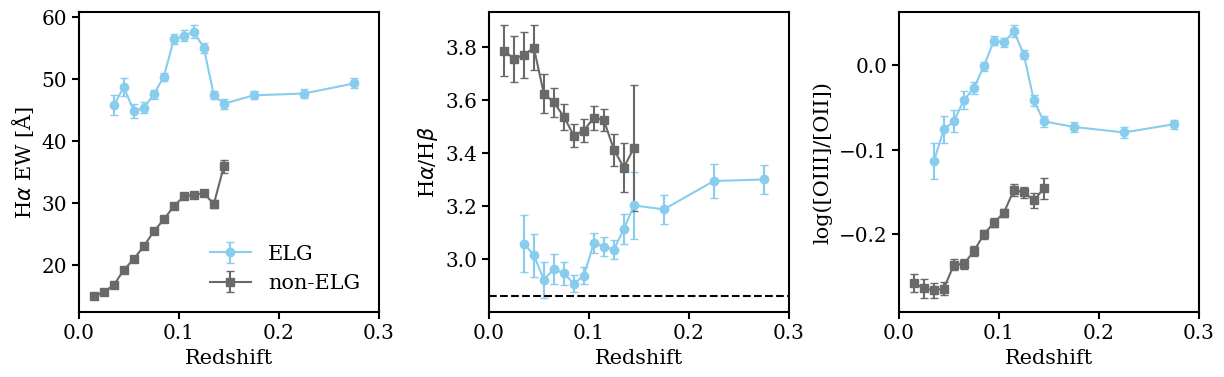

In [110]:

# Create figure
fig, ax = make_subplots(ncol=3,nrow=1,return_fig=True)

plot_config = [
    (ax[0], "halpha_ew", r"H$\alpha$ EW [Å]"),
    (ax[1], "ha_hb", r"H$\alpha$/H$\beta$"),
    (ax[2], "log_oiii_oii", r"log([OIII]/[OII])"),
]

for axi, name, ylabel in plot_config:
    axi.errorbar(zcens, data[name]["elg"], yerr=data[name]["elg_err"],
                 fmt='o-', capsize=3, label="ELG",color=sample_colors["ELG"])
    axi.errorbar(zcens, data[name]["noelg"], yerr=data[name]["noelg_err"],
                 fmt='s-', capsize=3, label="non-ELG",color="dimgrey")
    axi.set_ylabel(ylabel,fontsize = 15)
    axi.set_xlabel(r"Redshift",fontsize = 15)
    axi.set_xlim([0, 0.3])
    
    
ax[1].axhline(2.86,color="k",ls="--")
ax[0].legend(frameon=False,fontsize = 15)

plt.tight_layout()
plt.show()


7.25 7.5
Total number selected = 4091
Total number selected = 905
Loading existing ELG stack for log(M*)=[7.25, 7.50]
Loading existing NO-ELG stack for log(M*)=[7.25, 7.50]


/tmp/ipykernel_1170682/19088756.py:148: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axi.set_ylim([0, np.nanmax(stack_spec_elg) * 1.1])


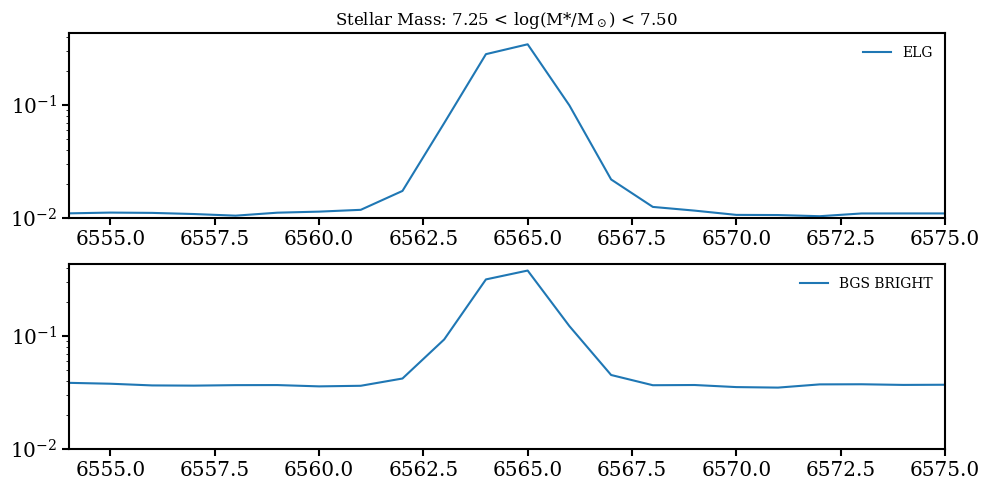

In [195]:
# =============================================================================
# Main loop - Stellar Mass Bins
# =============================================================================
import pickle
from astropy.io import fits

stack_spec_elg_mstar_dict = {}
stack_spec_noelg_mstar_dict = {}
line_ratios_elg_mstar_dict = {}
line_ratios_noelg_mstar_dict = {}
overwrite = False
stack_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/"

# Create directory if it doesn't exist
os.makedirs(stack_path, exist_ok=True)

# Define stellar mass bins (0.25 dex bins)
# Adjust the range as needed for your data
mstar_bins = np.arange(6.0, 9.25, 0.25) 

# Redshift range (no limit, but specify the full range)
z_min_global = 0.0
z_max_global = 0.5

for i in range(5,6):
    mstar_min_i = mstar_bins[i]
    mstar_max_i = mstar_bins[i + 1]

    print(mstar_min_i, mstar_max_i)
    
    # Select samples in this stellar mass bin (across full redshift range)
    elg_sub_cat_i = select_sample(tot_cat, "ELG", z_min=z_min_global, z_max=z_max_global, 
                                   logmstar_min=mstar_min_i, logmstar_max=mstar_max_i)
    noelg_sub_cat_i = select_sample(tot_cat, "NO_ELG", z_min=z_min_global, z_max=z_max_global,
                                     logmstar_min=mstar_min_i, logmstar_max=mstar_max_i)
    
    stack_nlim = 500
    
    # ----------------------------
    # ELG stack
    # ----------------------------
    if len(elg_sub_cat_i) > stack_nlim:
        stack_file_elg = stack_path + f"stacks_spec_elg_mstar_{mstar_min_i:.2f}_{mstar_max_i:.2f}.pkl"
        
        if os.path.exists(stack_file_elg) and overwrite == False:
            print(f"Loading existing ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}]")
            with open(stack_file_elg, 'rb') as f:
                saved_data = pickle.load(f)
                stack_spec_elg = saved_data['stack_spec']
                stack_err_elg = saved_data['stack_err']
                all_stacks_elg = saved_data['all_stacks']
        else:
            print(f"Computing ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(elg_sub_cat_i)})")
            flux_elg_i, ivar_elg_i, haf_elg_i, tgids_elg_i = get_sample_spectra_with_halpha(
                elg_sub_cat_i, spectra_data
            )
            stack_spec_elg, stack_err_elg, all_stacks_elg = bootstrap_stack_fast_capped(
                flux_elg_i, ivar_elg_i, haf_elg_i, wave, random_seed=42
            )
            
            # Save the stacked spectra
            save_data = {
                'stack_spec': stack_spec_elg,
                'stack_err': stack_err_elg,
                'all_stacks': all_stacks_elg,
                'mstar_min': mstar_min_i,
                'mstar_max': mstar_max_i,
                'z_min': z_min_global,
                'z_max': z_max_global,
                'n_galaxies': len(elg_sub_cat_i)
            }
            with open(stack_file_elg, 'wb') as f:
                pickle.dump(save_data, f)
            print(f"Saved ELG stack to {stack_file_elg}")
            
        # Compute line ratios directly from bootstrap realizations
        line_ratios_elg_mstar_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_elg, LINE_WINDOWS
        )
    else:
        print(f"Skipping ELG for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(elg_sub_cat_i)} < {stack_nlim})")
        stack_spec_elg = np.full_like(wave, np.nan)
        line_ratios_elg_mstar_dict[i] = None


    ##now let us do some more direct checks?
    
    # ----------------------------
    # NO-ELG stack
    # ----------------------------
    if len(noelg_sub_cat_i) > stack_nlim:
        stack_file_noelg = stack_path + f"stacks_spec_noelg_mstar_{mstar_min_i:.2f}_{mstar_max_i:.2f}.pkl"
        
        if os.path.exists(stack_file_noelg) and overwrite == False:
            print(f"Loading existing NO-ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}]")
            with open(stack_file_noelg, 'rb') as f:
                saved_data = pickle.load(f)
                stack_spec_noelg = saved_data['stack_spec']
                stack_err_noelg = saved_data['stack_err']
                all_stacks_noelg = saved_data['all_stacks']
        else:
            print(f"Computing NO-ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(noelg_sub_cat_i)})")
            flux_noelg_i, ivar_noelg_i, haf_noelg_i, tgids_noelg_i = get_sample_spectra_with_halpha(
                noelg_sub_cat_i, spectra_data
            )
            stack_spec_noelg, stack_err_noelg, all_stacks_noelg = bootstrap_stack_fast_capped(
                flux_noelg_i, ivar_noelg_i, haf_noelg_i, wave, random_seed=42
            )
            
            # Save the stacked spectra
            save_data = {
                'stack_spec': stack_spec_noelg,
                'stack_err': stack_err_noelg,
                'all_stacks': all_stacks_noelg,
                'mstar_min': mstar_min_i,
                'mstar_max': mstar_max_i,
                'z_min': z_min_global,
                'z_max': z_max_global,
                'n_galaxies': len(noelg_sub_cat_i)
            }
            with open(stack_file_noelg, 'wb') as f:
                pickle.dump(save_data, f)
            print(f"Saved NO-ELG stack to {stack_file_noelg}")
            
        line_ratios_noelg_mstar_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_noelg, LINE_WINDOWS
        )
    else:
        print(f"Skipping NO-ELG for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(noelg_sub_cat_i)} < {stack_nlim})")
        stack_spec_noelg = np.full_like(wave, np.nan)
        line_ratios_noelg_mstar_dict[i] = None
    
    # Plot stacked spectra
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    ax[0].set_title(f"Stellar Mass: {mstar_min_i:.2f} < log(M*/M$_\\odot$) < {mstar_max_i:.2f}")
    ax[0].plot(wave, stack_spec_elg, label="ELG")
    ax[1].plot(wave, stack_spec_noelg, label="BGS BRIGHT")

    for axi in ax:
        # axi.set_xlim([3600, 9500])
        axi.set_xlim([LINE_WINDOWS["Halpha"][0]-5,LINE_WINDOWS["Halpha"][1]+5] )
        axi.set_yscale("log")
        axi.set_ylim([1e-2,0.5])
        axi.legend()
        
    try:
        for axi in ax:
            axi.set_ylim([0, np.nanmax(stack_spec_elg) * 1.1])
    except:
        pass
        
    plt.tight_layout()
    plt.show()
    

In [198]:
from elg_explore import boxcar_line_flux

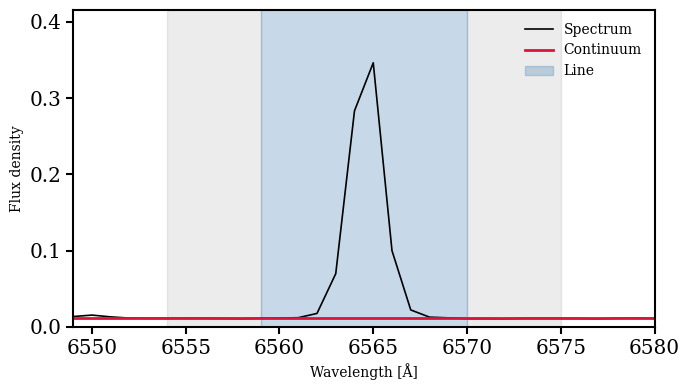

(0.7754877, 0.011050614)

In [203]:
boxcar_line_flux(wave,
    stack_spec_elg,
    (LINE_WINDOWS["Halpha"][0], LINE_WINDOWS["Halpha"][1]),
    cont_width=LINE_WINDOWS["Halpha"][2],
    plot_true=True)

Total number selected = 29
Total number selected = 10
Skipping ELG for log(M*)=[6.00, 6.25] (N=29 < 500)
Skipping NO-ELG for log(M*)=[6.00, 6.25] (N=10 < 500)


/tmp/ipykernel_1170682/3476750915.py:140: RuntimeWarning: All-NaN slice encountered
  axi.set_ylim([0, np.nanmax(stack_spec_elg) * 1.1])


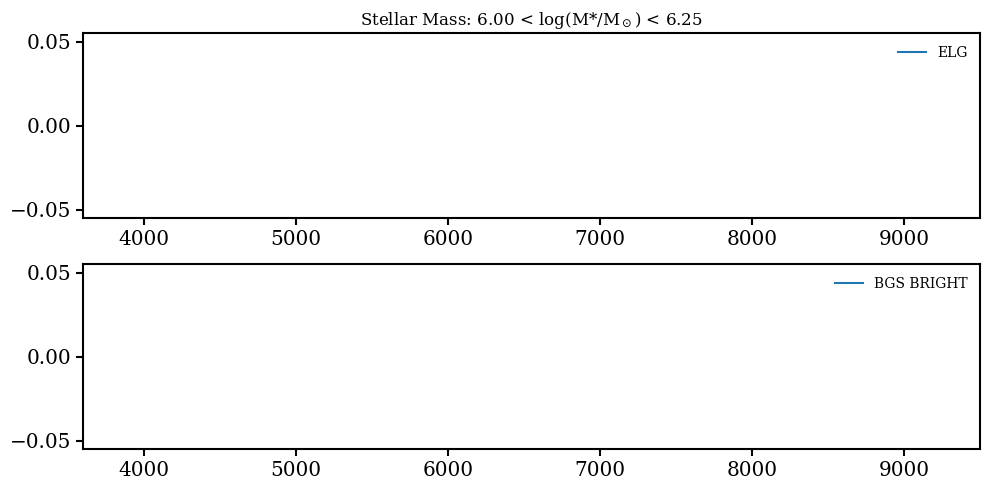

--
Total number selected = 65
Total number selected = 33
Skipping ELG for log(M*)=[6.25, 6.50] (N=65 < 500)
Skipping NO-ELG for log(M*)=[6.25, 6.50] (N=33 < 500)


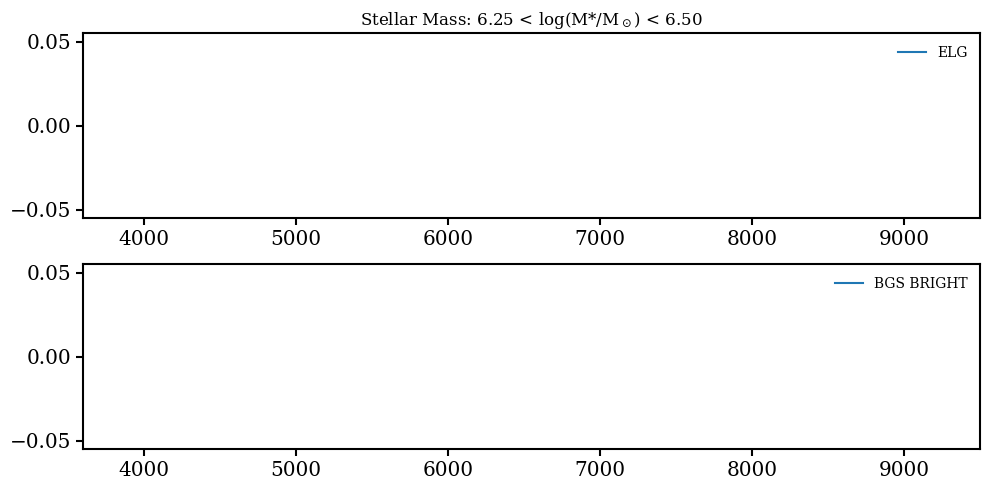

--
Total number selected = 241
Total number selected = 76
Skipping ELG for log(M*)=[6.50, 6.75] (N=241 < 500)
Skipping NO-ELG for log(M*)=[6.50, 6.75] (N=76 < 500)


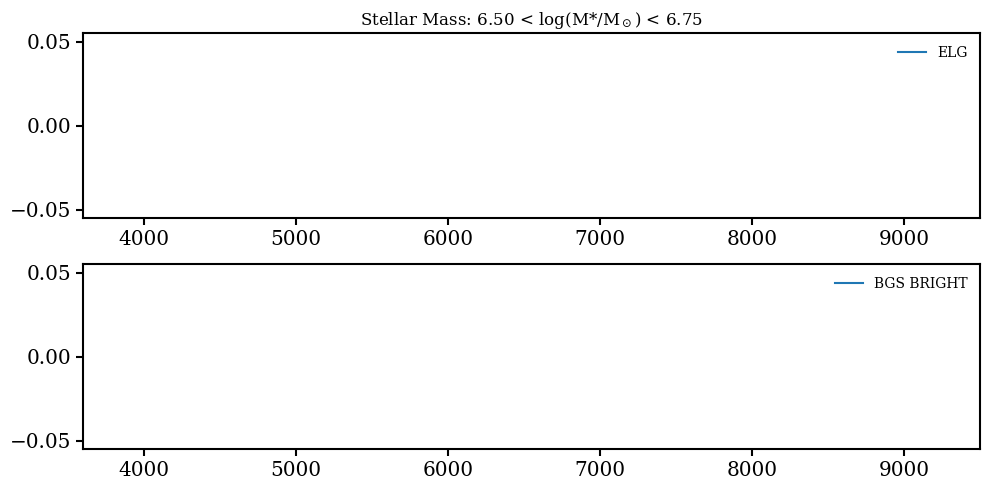

--
Total number selected = 751
Total number selected = 156
Loading existing ELG stack for log(M*)=[6.75, 7.00]
Skipping NO-ELG for log(M*)=[6.75, 7.00] (N=156 < 500)


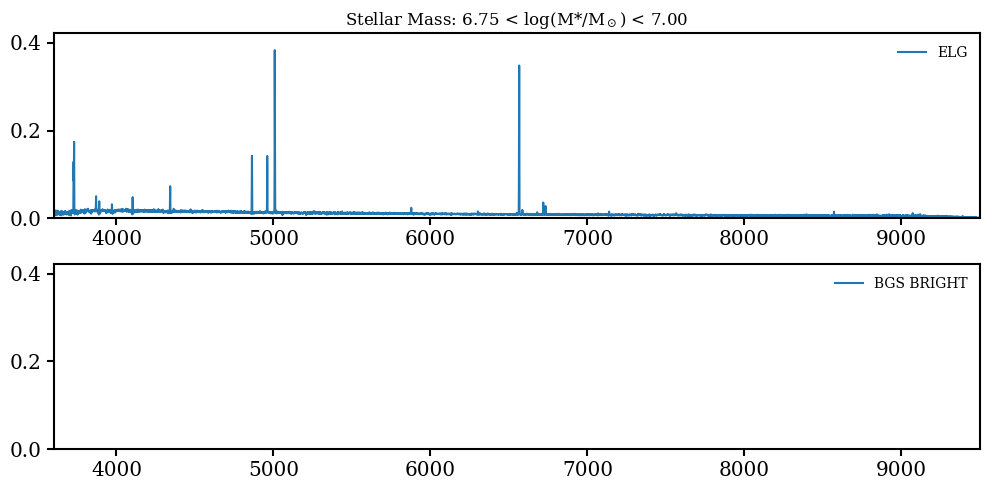

--
Total number selected = 1733
Total number selected = 397
Loading existing ELG stack for log(M*)=[7.00, 7.25]
Skipping NO-ELG for log(M*)=[7.00, 7.25] (N=397 < 500)


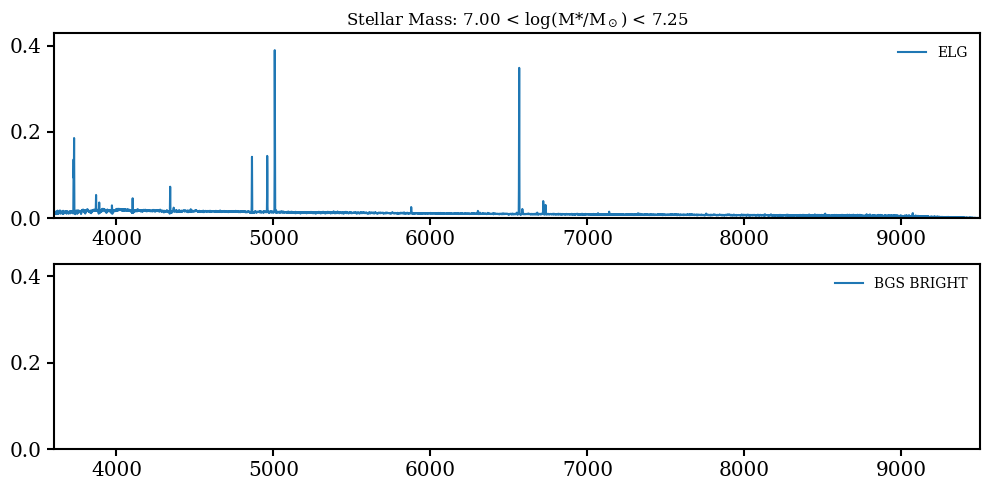

--
Total number selected = 4091
Total number selected = 905
Loading existing ELG stack for log(M*)=[7.25, 7.50]
Loading existing NO-ELG stack for log(M*)=[7.25, 7.50]


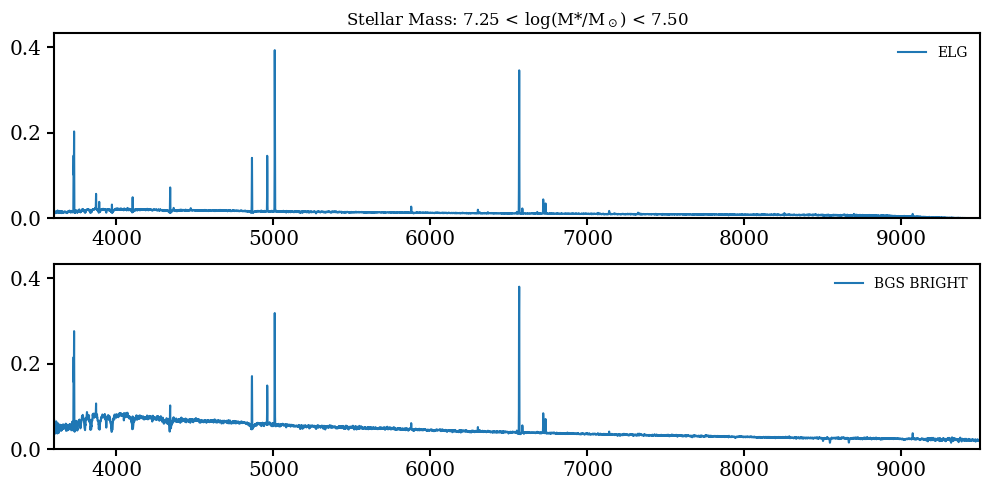

--
Total number selected = 8654
Total number selected = 1859
Loading existing ELG stack for log(M*)=[7.50, 7.75]
Loading existing NO-ELG stack for log(M*)=[7.50, 7.75]


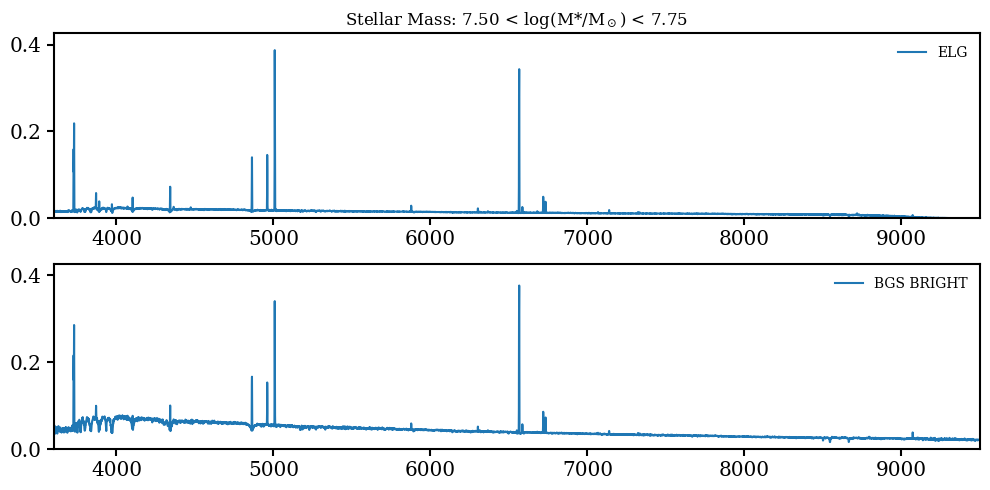

--
Total number selected = 15464
Total number selected = 3885
Loading existing ELG stack for log(M*)=[7.75, 8.00]
Loading existing NO-ELG stack for log(M*)=[7.75, 8.00]


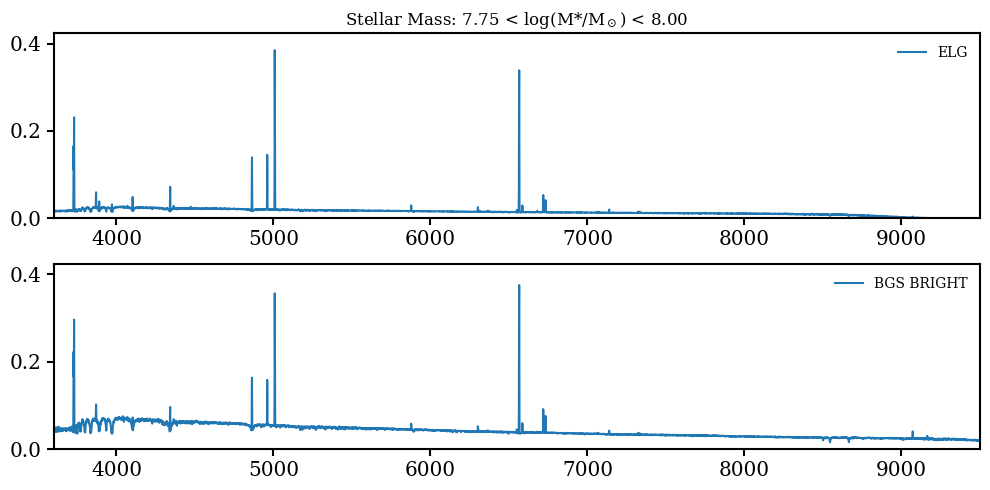

--
Total number selected = 22837
Total number selected = 8073
Loading existing ELG stack for log(M*)=[8.00, 8.25]
Loading existing NO-ELG stack for log(M*)=[8.00, 8.25]


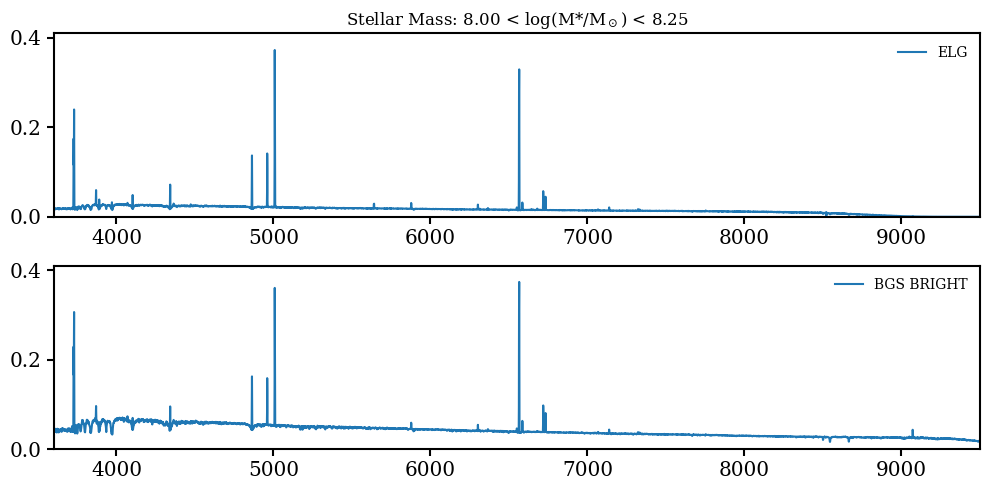

--
Total number selected = 25972
Total number selected = 15715
Loading existing ELG stack for log(M*)=[8.25, 8.50]
Loading existing NO-ELG stack for log(M*)=[8.25, 8.50]


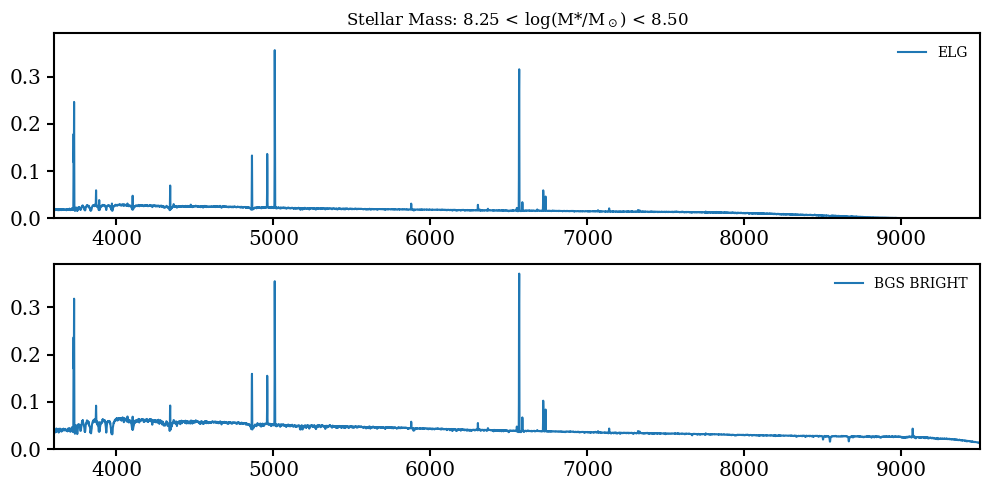

--
Total number selected = 24204
Total number selected = 29237
Loading existing ELG stack for log(M*)=[8.50, 8.75]
Loading existing NO-ELG stack for log(M*)=[8.50, 8.75]


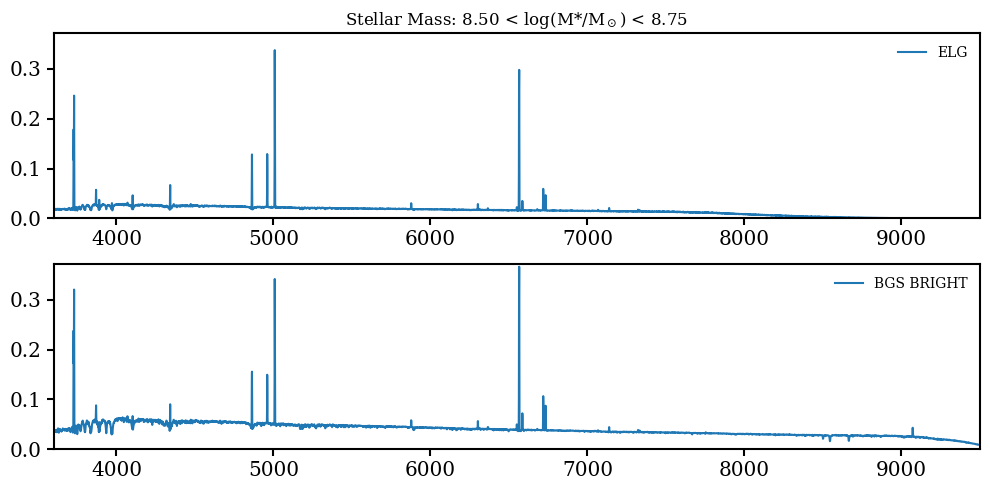

--
Total number selected = 19010
Total number selected = 49703
Loading existing ELG stack for log(M*)=[8.75, 9.00]
Loading existing NO-ELG stack for log(M*)=[8.75, 9.00]


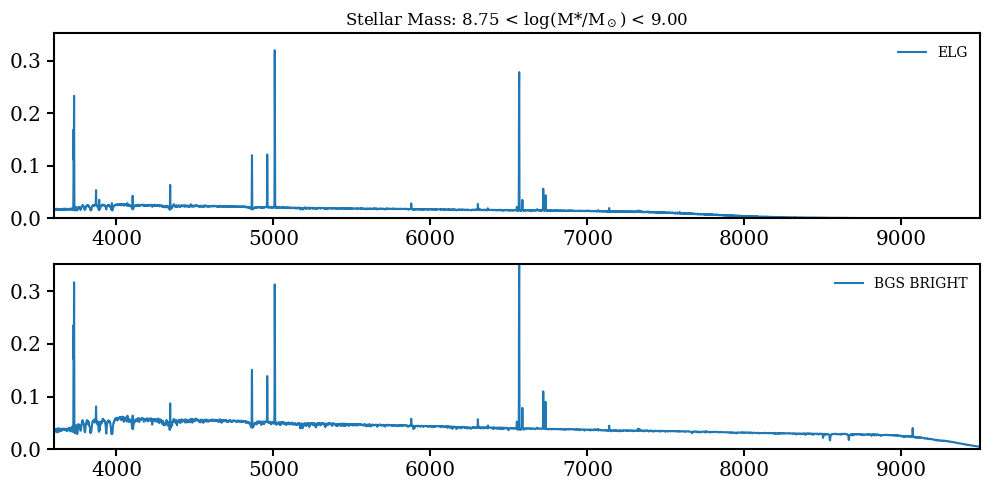

--


In [168]:
# =============================================================================
# Main loop - Stellar Mass Bins
# =============================================================================
import pickle
from astropy.io import fits

stack_spec_elg_mstar_dict = {}
stack_spec_noelg_mstar_dict = {}
line_ratios_elg_mstar_dict = {}
line_ratios_noelg_mstar_dict = {}
overwrite = False
stack_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar/"

# Create directory if it doesn't exist
os.makedirs(stack_path, exist_ok=True)

# Define stellar mass bins (0.25 dex bins)
# Adjust the range as needed for your data
mstar_bins = np.arange(6.0, 9.25, 0.25) 

# Redshift range (no limit, but specify the full range)
z_min_global = 0.0
z_max_global = 0.5

for i in range(len(mstar_bins) - 1):
    mstar_min_i = mstar_bins[i]
    mstar_max_i = mstar_bins[i + 1]
    
    # Select samples in this stellar mass bin (across full redshift range)
    elg_sub_cat_i = select_sample(tot_cat, "ELG", z_min=z_min_global, z_max=z_max_global, 
                                   logmstar_min=mstar_min_i, logmstar_max=mstar_max_i)
    noelg_sub_cat_i = select_sample(tot_cat, "NO_ELG", z_min=z_min_global, z_max=z_max_global,
                                     logmstar_min=mstar_min_i, logmstar_max=mstar_max_i)
    
    stack_nlim = 500
    
    # ----------------------------
    # ELG stack
    # ----------------------------
    if len(elg_sub_cat_i) > stack_nlim:
        stack_file_elg = stack_path + f"stacks_spec_elg_mstar_{mstar_min_i:.2f}_{mstar_max_i:.2f}.pkl"
        
        if os.path.exists(stack_file_elg) and overwrite == False:
            print(f"Loading existing ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}]")
            with open(stack_file_elg, 'rb') as f:
                saved_data = pickle.load(f)
                stack_spec_elg = saved_data['stack_spec']
                stack_err_elg = saved_data['stack_err']
                all_stacks_elg = saved_data['all_stacks']
        else:
            print(f"Computing ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(elg_sub_cat_i)})")
            flux_elg_i, ivar_elg_i, haf_elg_i, tgids_elg_i = get_sample_spectra_with_halpha(
                elg_sub_cat_i, spectra_data
            )
            stack_spec_elg, stack_err_elg, all_stacks_elg = bootstrap_stack_fast_capped(
                flux_elg_i, ivar_elg_i, haf_elg_i, wave, random_seed=42
            )
            
            # Save the stacked spectra
            save_data = {
                'stack_spec': stack_spec_elg,
                'stack_err': stack_err_elg,
                'all_stacks': all_stacks_elg,
                'mstar_min': mstar_min_i,
                'mstar_max': mstar_max_i,
                'z_min': z_min_global,
                'z_max': z_max_global,
                'n_galaxies': len(elg_sub_cat_i)
            }
            with open(stack_file_elg, 'wb') as f:
                pickle.dump(save_data, f)
            print(f"Saved ELG stack to {stack_file_elg}")
            
        # Compute line ratios directly from bootstrap realizations
        line_ratios_elg_mstar_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_elg, LINE_WINDOWS
        )
    else:
        print(f"Skipping ELG for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(elg_sub_cat_i)} < {stack_nlim})")
        stack_spec_elg = np.full_like(wave, np.nan)
        line_ratios_elg_mstar_dict[i] = None
    
    # ----------------------------
    # NO-ELG stack
    # ----------------------------
    if len(noelg_sub_cat_i) > stack_nlim:
        stack_file_noelg = stack_path + f"stacks_spec_noelg_mstar_{mstar_min_i:.2f}_{mstar_max_i:.2f}.pkl"
        
        if os.path.exists(stack_file_noelg) and overwrite == False:
            print(f"Loading existing NO-ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}]")
            with open(stack_file_noelg, 'rb') as f:
                saved_data = pickle.load(f)
                stack_spec_noelg = saved_data['stack_spec']
                stack_err_noelg = saved_data['stack_err']
                all_stacks_noelg = saved_data['all_stacks']
        else:
            print(f"Computing NO-ELG stack for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(noelg_sub_cat_i)})")
            flux_noelg_i, ivar_noelg_i, haf_noelg_i, tgids_noelg_i = get_sample_spectra_with_halpha(
                noelg_sub_cat_i, spectra_data
            )
            stack_spec_noelg, stack_err_noelg, all_stacks_noelg = bootstrap_stack_fast_capped(
                flux_noelg_i, ivar_noelg_i, haf_noelg_i, wave, random_seed=42
            )
            
            # Save the stacked spectra
            save_data = {
                'stack_spec': stack_spec_noelg,
                'stack_err': stack_err_noelg,
                'all_stacks': all_stacks_noelg,
                'mstar_min': mstar_min_i,
                'mstar_max': mstar_max_i,
                'z_min': z_min_global,
                'z_max': z_max_global,
                'n_galaxies': len(noelg_sub_cat_i)
            }
            with open(stack_file_noelg, 'wb') as f:
                pickle.dump(save_data, f)
            print(f"Saved NO-ELG stack to {stack_file_noelg}")
            
        line_ratios_noelg_mstar_dict[i] = compute_line_ratios_bootstrap(
            wave, all_stacks_noelg, LINE_WINDOWS
        )
    else:
        print(f"Skipping NO-ELG for log(M*)=[{mstar_min_i:.2f}, {mstar_max_i:.2f}] (N={len(noelg_sub_cat_i)} < {stack_nlim})")
        stack_spec_noelg = np.full_like(wave, np.nan)
        line_ratios_noelg_mstar_dict[i] = None
    
    # Plot stacked spectra
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    ax[0].set_title(f"Stellar Mass: {mstar_min_i:.2f} < log(M*/M$_\\odot$) < {mstar_max_i:.2f}")
    ax[0].plot(wave, stack_spec_elg, label="ELG")
    ax[1].plot(wave, stack_spec_noelg, label="BGS BRIGHT")

    for axi in ax:
        axi.set_xlim([3600, 9500])
        axi.legend()
        
    try:
        for axi in ax:
            axi.set_ylim([0, np.nanmax(stack_spec_elg) * 1.1])
    except:
        pass
        
    plt.tight_layout()
    plt.show()
    
    stack_spec_elg_mstar_dict[i] = stack_spec_elg
    stack_spec_noelg_mstar_dict[i] = stack_spec_noelg
    print("--")

In [113]:
mstar_cens = 0.5 * (mstar_bins[1:] + mstar_bins[:-1])

In [171]:
# =============================================================================
# Plotting line ratios with error bars
# =============================================================================

# Extract values and errors into arrays
ratio_names = ["halpha_flux", "halpha_ew", "ha_hb", "log_oiii_oii", "log_oiii_hb", "log_sii_halpha"]
mstar_data = {name: {"elg": [], "elg_err": [], "noelg": [], "noelg_err": []} for name in ratio_names}

for i in range(len(mstar_cens)):
    elg = line_ratios_elg_mstar_dict[i]
    noelg = line_ratios_noelg_mstar_dict[i]
    
    for name in ratio_names:
        if elg is not None:
            mstar_data[name]["elg"].append(elg[name]["val"])
            mstar_data[name]["elg_err"].append(elg[name]["err"])
        else:
            mstar_data[name]["elg"].append(np.nan)
            mstar_data[name]["elg_err"].append(np.nan)
        
        if noelg is not None:
            mstar_data[name]["noelg"].append(noelg[name]["val"])
            mstar_data[name]["noelg_err"].append(noelg[name]["err"])
        else:
            mstar_data[name]["noelg"].append(np.nan)
            mstar_data[name]["noelg_err"].append(np.nan)

# Convert to arrays
for name in ratio_names:
    for key in mstar_data[name]:
        mstar_data[name][key] = np.array(mstar_data[name][key])

In [172]:

# # Create figure
# fig, ax = plt.subplots(2, 3, figsize=(12, 6))

# plot_config = [
#     (ax[0, 0], "halpha_ew", r"H$\alpha$ EW [Å]"),
#     (ax[0, 1], "ha_hb", r"H$\alpha$/H$\beta$"),
#     (ax[0, 2], "log_oiii_oii", r"log([OIII]/[OII])"),
#     (ax[1, 0], "log_oiii_hb", r"log([OIII]/H$\beta$)"),
#     (ax[1, 1], "log_sii_halpha", r"log([SII]/H$\alpha$)"),
# ]

# for axi, name, ylabel in plot_config:
#     axi.errorbar(mstar_cens, data[name]["elg"], yerr=data[name]["elg_err"],
#                  fmt='o-', capsize=3, label="ELG")
#     axi.errorbar(mstar_cens, data[name]["noelg"], yerr=data[name]["noelg_err"],
#                  fmt='s-', capsize=3, label="non-ELG")
#     axi.set_ylabel(ylabel)
#     axi.set_xlabel("z")
#     axi.set_xlim([6, 9])

# ax[1, 2].axis("off")
# ax[1, 2].legend(*ax[0, 0].get_legend_handles_labels(), loc="center", fontsize=12)

# plt.tight_layout()
# plt.show()


In [116]:

# # Create figure
# fig, ax = make_subplots(ncol=3,nrow=1,return_fig=True)

# plot_config = [
#     (ax[0], "halpha_ew", r"H$\alpha$ EW [Å]"),
#     (ax[1], "ha_hb", r"H$\alpha$/H$\beta$"),
#     (ax[2], "log_oiii_oii", r"log$_{10}$([OIII]/[OII])"),
# ]

# for axi, name, ylabel in plot_config:
#     axi.errorbar(mstar_cens, data[name]["elg"], yerr=data[name]["elg_err"],
#                  fmt='o-', capsize=3, label="ELG",color=sample_colors["ELG"])
#     axi.errorbar(mstar_cens, data[name]["noelg"], yerr=data[name]["noelg_err"],
#                  fmt='s-', capsize=3, label="non-ELG",color="firebrick",alpha=0.85)
#     axi.set_ylabel(ylabel,fontsize = 15)
#     axi.set_xlabel(r"Stellar Mass $M_{\bigstar}$",fontsize = 15)
#     axi.set_xlim([6.75, 9])
    

# ax[1].axhline(2.86,color="k",ls="--")
# ax[0].legend(frameon=False,fontsize = 15)

# plt.tight_layout()
# plt.show()


## Final redshift stack plot!:

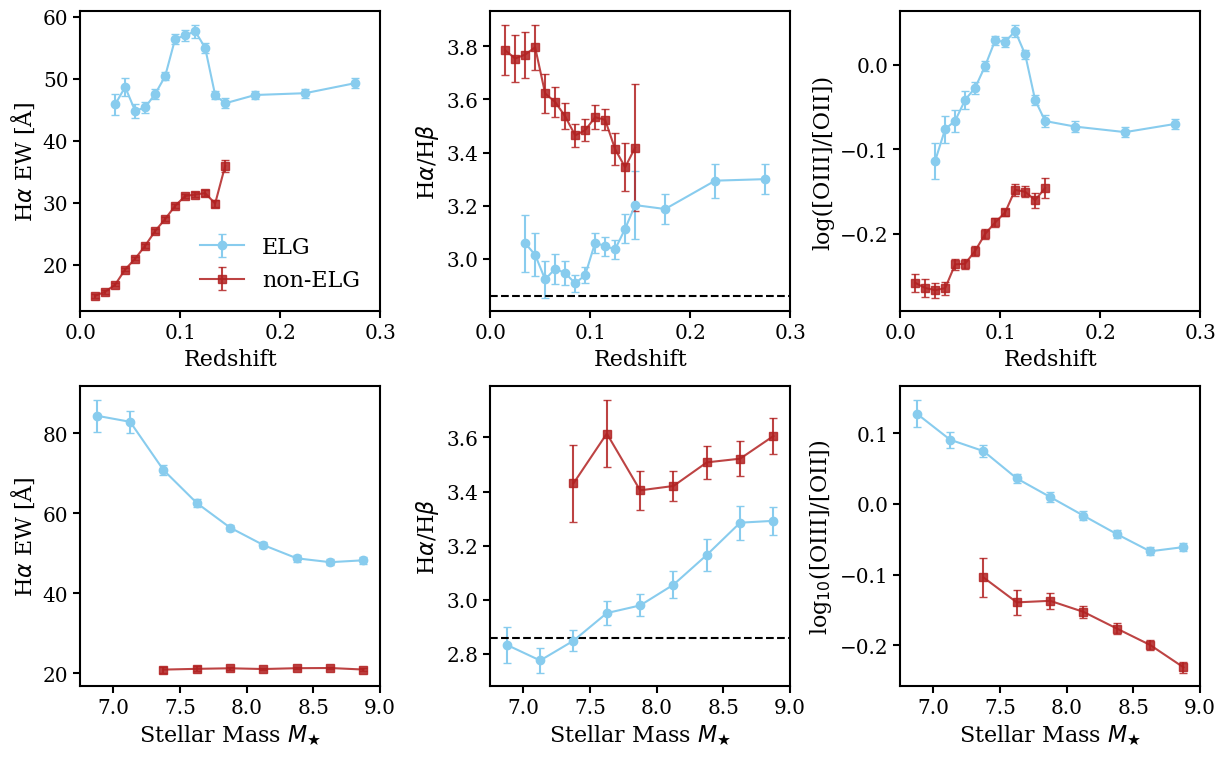

In [122]:
fig,ax = make_subplots(ncol=3,nrow=2, return_fig=True,row_spacing=0.75)

label_size =  16


plot_config = [
    (ax[3], "halpha_ew", r"H$\alpha$ EW [Å]"),
    (ax[4], "ha_hb", r"H$\alpha$/H$\beta$"),
    (ax[5], "log_oiii_oii", r"log([OIII]/[OII])"),
]

for axi, name, ylabel in plot_config:
    axi.errorbar(zcens, data[name]["elg"], yerr=data[name]["elg_err"],
                 fmt='o-', capsize=3, label="ELG",color=sample_colors["ELG"])
    
    axi.errorbar(zcens, data[name]["noelg"], yerr=data[name]["noelg_err"],
                 fmt='s-', capsize=3, label="non-ELG",color="firebrick",alpha=0.85)
    axi.set_ylabel(ylabel,fontsize = label_size)
    axi.set_xlabel(r"Redshift",fontsize = label_size)
    axi.set_xlim([0, 0.3])
    
ax[4].axhline(2.86,color="k",ls="--")

#################

plot_config = [
    (ax[0], "halpha_ew", r"H$\alpha$ EW [Å]"),
    (ax[1], "ha_hb", r"H$\alpha$/H$\beta$"),
    (ax[2], "log_oiii_oii", r"log$_{10}$([OIII]/[OII])"),
]

for axi, name, ylabel in plot_config:
    axi.errorbar(mstar_cens, mstar_data[name]["elg"], yerr=mstar_data[name]["elg_err"],
                 fmt='o-', capsize=3, label="ELG",color=sample_colors["ELG"])
    
    axi.errorbar(mstar_cens, mstar_data[name]["noelg"], yerr=mstar_data[name]["noelg_err"],
                 fmt='s-', capsize=3, label="non-ELG",color="firebrick",alpha=0.85)
    
    axi.set_ylabel(ylabel,fontsize = label_size)
    axi.set_xlabel(r"Stellar Mass $M_{\bigstar}$",fontsize = label_size)
    axi.set_xlim([6.75, 9])
    axi.set_xticks([7,7.5,8,8.5,9])
    

ax[1].axhline(2.86,color="k",ls="--")
ax[3].legend(frameon=False,fontsize = label_size)

plt.show()




Total number selected = 29
Total number selected = 10


/tmp/ipykernel_1170682/2575413500.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


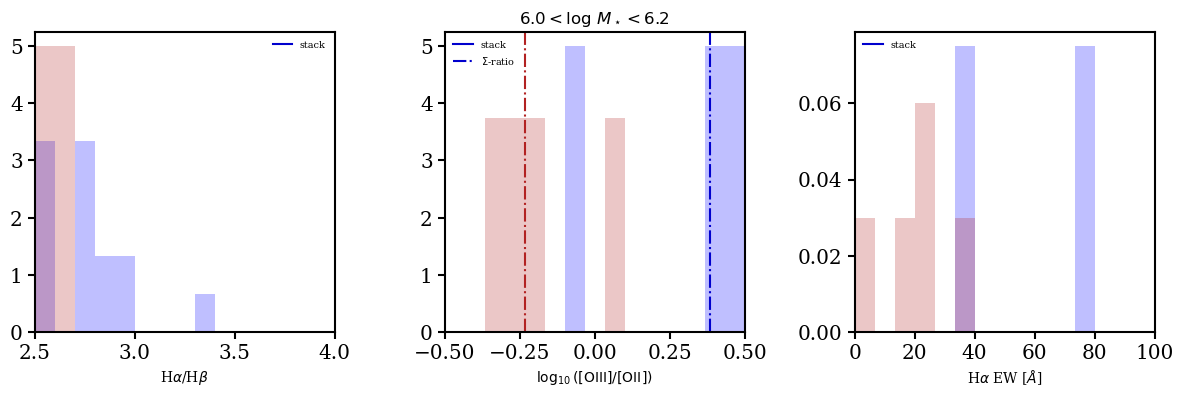

Total number selected = 65
Total number selected = 33


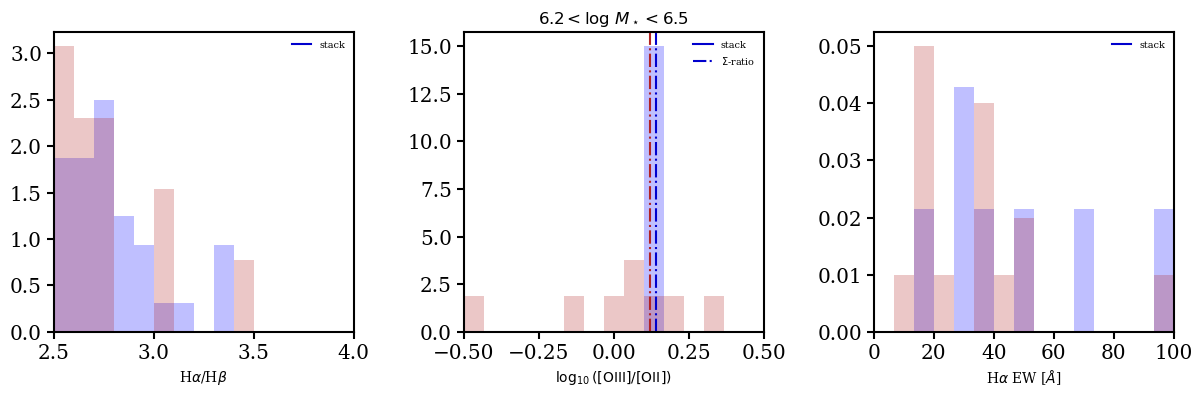

Total number selected = 241
Total number selected = 76


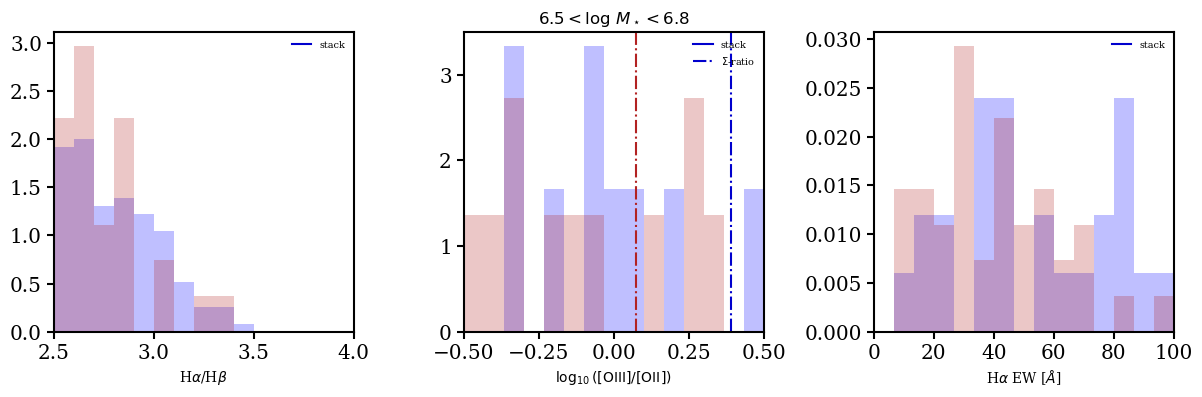

Total number selected = 751
Total number selected = 156


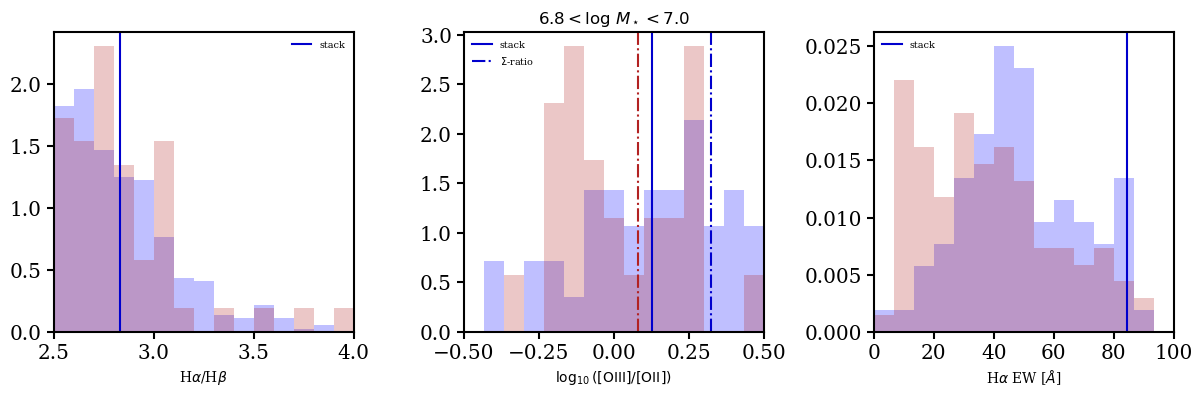

Total number selected = 1733
Total number selected = 397


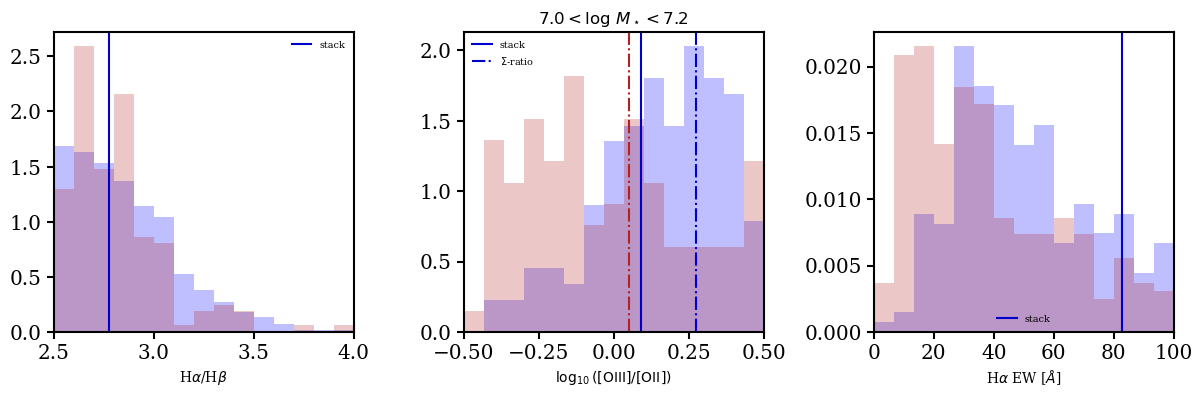

Total number selected = 4091
Total number selected = 905


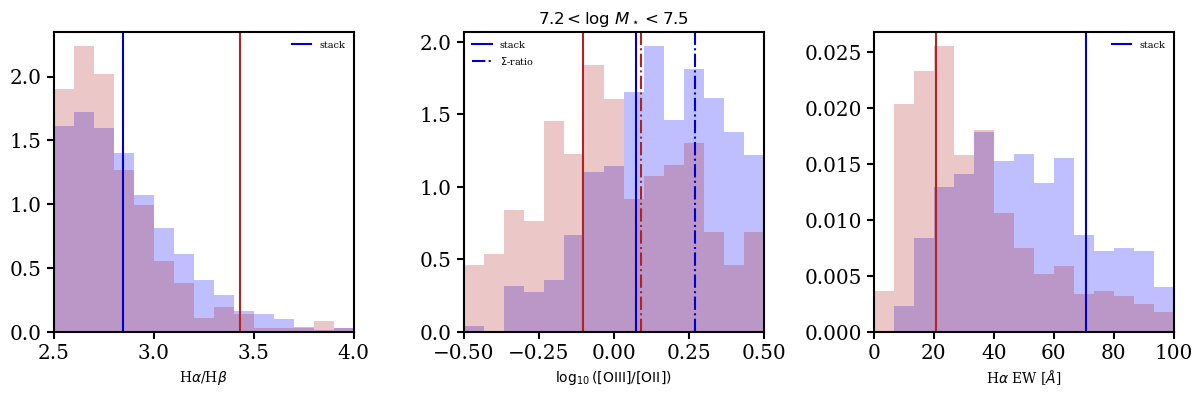

Total number selected = 8654
Total number selected = 1859


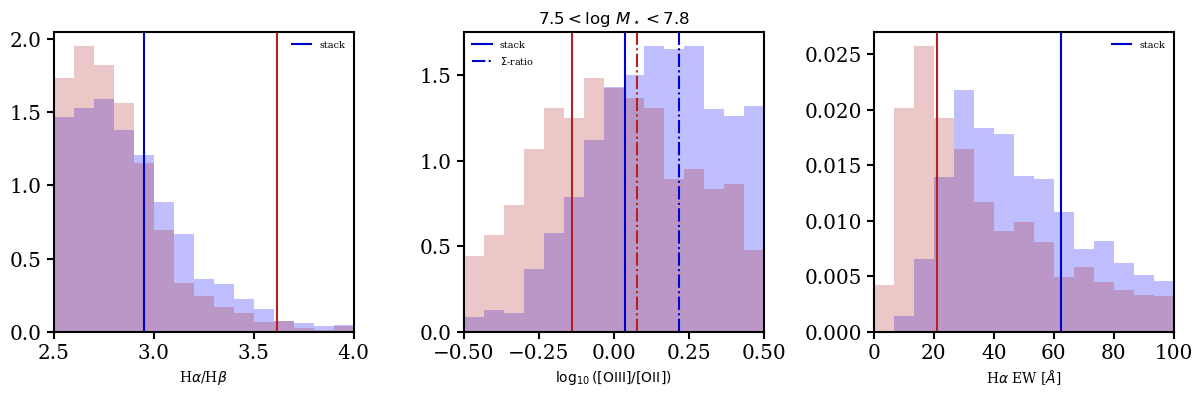

Total number selected = 15464
Total number selected = 3885


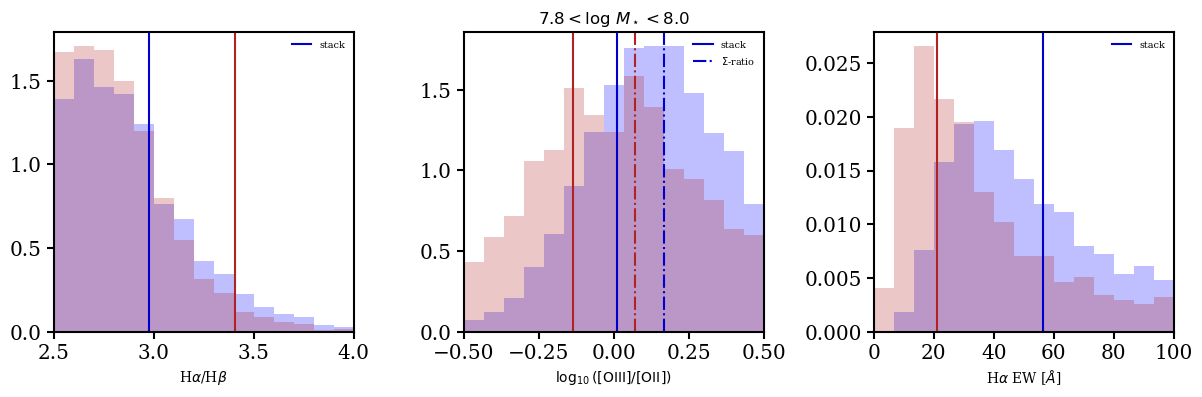

Total number selected = 22837
Total number selected = 8073


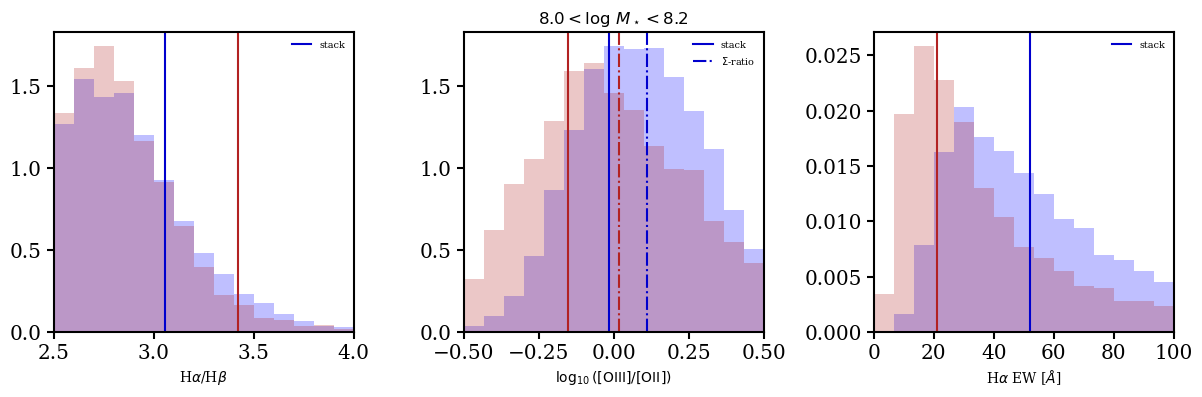

Total number selected = 25972
Total number selected = 15715


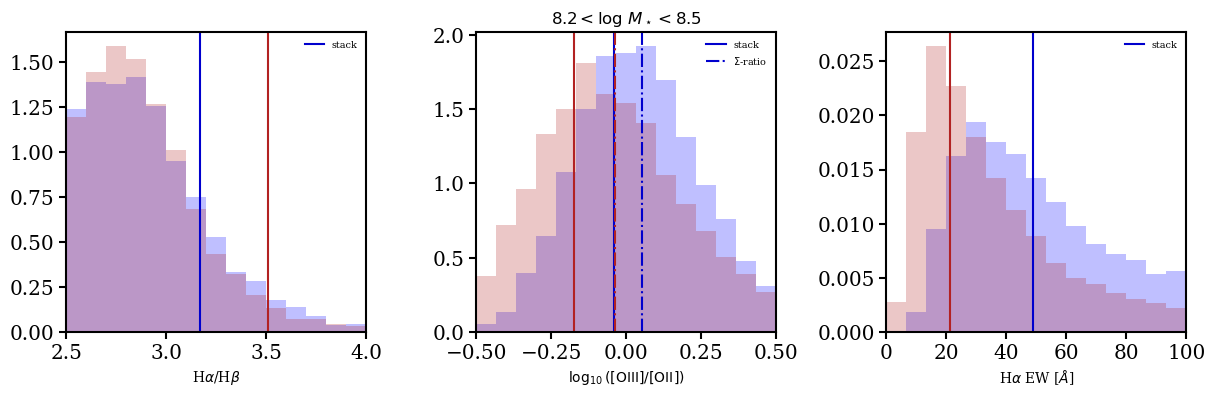

Total number selected = 24204
Total number selected = 29237


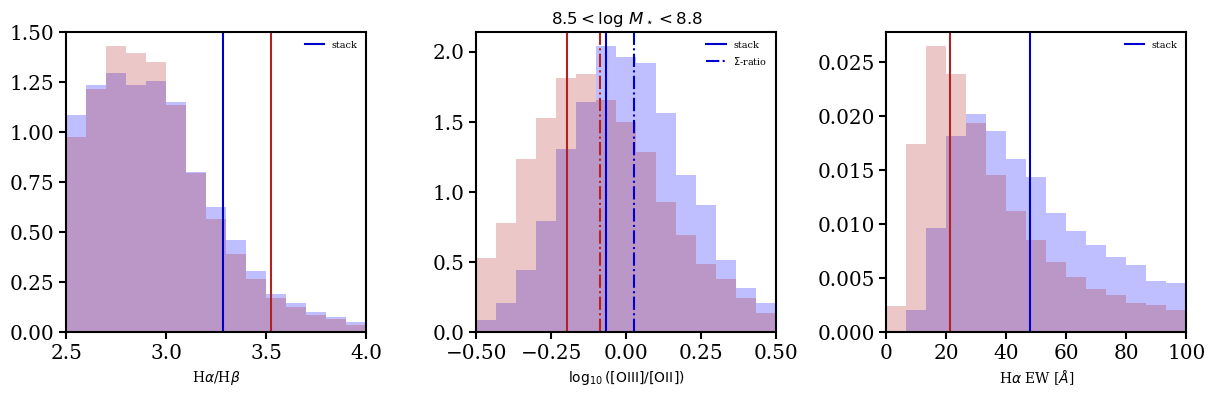

Total number selected = 19010
Total number selected = 49703


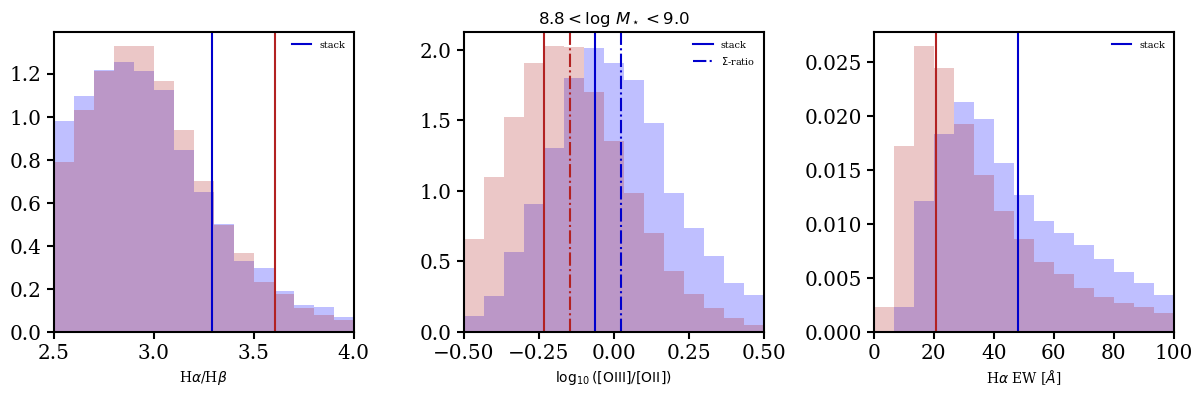

In [167]:
## let us confirm that the stacking correctly gives us average line ratios and ew!

for i in range(len(mstar_bins) - 1):
    mstar_min_i = mstar_bins[i]
    mstar_max_i = mstar_bins[i + 1]

    # Select samples in this stellar mass bin
    elg_sub_cat_i = select_sample(tot_cat, "ELG", z_min=z_min_global, z_max=z_max_global,
                                   logmstar_min=mstar_min_i, logmstar_max=mstar_max_i)
    noelg_sub_cat_i = select_sample(tot_cat, "NO_ELG", z_min=z_min_global, z_max=z_max_global,
                                     logmstar_min=mstar_min_i, logmstar_max=mstar_max_i)

    # --- Helper to compute SNR ---
    def get_snr(cat, flux_col, ivar_col):
        return cat[flux_col] * np.sqrt(cat[ivar_col])

    # --- Ha/Hb SNR cuts ---
    elg_hahb_cut = (get_snr(elg_sub_cat_i, "HALPHA_FLUX", "HALPHA_FLUX_IVAR") > 5) & \
                   (get_snr(elg_sub_cat_i, "HBETA_FLUX", "HBETA_FLUX_IVAR") > 5)
    noelg_hahb_cut = (get_snr(noelg_sub_cat_i, "HALPHA_FLUX", "HALPHA_FLUX_IVAR") > 5) & \
                     (get_snr(noelg_sub_cat_i, "HBETA_FLUX", "HBETA_FLUX_IVAR") > 5)

    # --- OIII/OII SNR cuts ---
    def oiii_oii_snr_cut(cat):
        oiii_ok = get_snr(cat, "OIII_5007_FLUX", "OIII_5007_FLUX_IVAR") > 5 \
                  if "OIII_5007_FLUX_IVAR" in cat.colnames else np.ones(len(cat), dtype=bool)
        oii_3726_ok = get_snr(cat, "OII_3726_FLUX", "OII_3726_FLUX_IVAR") > 5
        oii_3729_ok = get_snr(cat, "OII_3729_FLUX", "OII_3729_FLUX_IVAR") > 5
        return oiii_ok & oii_3726_ok & oii_3729_ok

    elg_oii_oiii_cut = oiii_oii_snr_cut(elg_sub_cat_i)
    noelg_oii_oiii_cut = oiii_oii_snr_cut(noelg_sub_cat_i)

    # --- Ha EW SNR cut (require SNR > 5 on EW) ---
    elg_ew_cut = get_snr(elg_sub_cat_i, "HALPHA_EW", "HALPHA_EW_IVAR") > 5
    noelg_ew_cut = get_snr(noelg_sub_cat_i, "HALPHA_EW", "HALPHA_EW_IVAR") > 5

    # =====================================================================
    # Compute individual galaxy quantities
    # =====================================================================

    # Ha/Hb
    hahb_elg = np.array(elg_sub_cat_i["HALPHA_FLUX"][elg_hahb_cut] /
                        elg_sub_cat_i["HBETA_FLUX"][elg_hahb_cut])
    hahb_noelg = np.array(noelg_sub_cat_i["HALPHA_FLUX"][noelg_hahb_cut] /
                          noelg_sub_cat_i["HBETA_FLUX"][noelg_hahb_cut])

    # log(OIII/OII)
    oii_flux_elg = np.array(elg_sub_cat_i["OII_3726_FLUX"] + elg_sub_cat_i["OII_3729_FLUX"])
    oiii_flux_elg = np.array(elg_sub_cat_i["OIII_5007_FLUX"])
    oii_flux_noelg = np.array(noelg_sub_cat_i["OII_3726_FLUX"] + noelg_sub_cat_i["OII_3729_FLUX"])
    oiii_flux_noelg = np.array(noelg_sub_cat_i["OIII_5007_FLUX"])

    log_o3o2_elg = np.log10(oiii_flux_elg[elg_oii_oiii_cut] / oii_flux_elg[elg_oii_oiii_cut])
    log_o3o2_noelg = np.log10(oiii_flux_noelg[noelg_oii_oiii_cut] / oii_flux_noelg[noelg_oii_oiii_cut])

    # Ha-normalized summed flux ratio (mimics stacking)
    def ha_weighted_log_ratio(oiii, oii, ha):
        return np.log10(np.nansum(oiii / ha) / np.nansum(oii / ha))

    ha_elg = np.array(elg_sub_cat_i["HALPHA_FLUX"][elg_oii_oiii_cut])
    ha_noelg = np.array(noelg_sub_cat_i["HALPHA_FLUX"][noelg_oii_oiii_cut])
    stacked_ratio_elg = ha_weighted_log_ratio(oiii_flux_elg[elg_oii_oiii_cut],
                                               oii_flux_elg[elg_oii_oiii_cut], ha_elg)
    stacked_ratio_noelg = ha_weighted_log_ratio(oiii_flux_noelg[noelg_oii_oiii_cut],
                                                 oii_flux_noelg[noelg_oii_oiii_cut], ha_noelg)

    # Ha EW
    ha_ew_elg = np.array(elg_sub_cat_i["HALPHA_EW"][elg_ew_cut])
    ha_ew_noelg = np.array(noelg_sub_cat_i["HALPHA_EW"][noelg_ew_cut])

    # =====================================================================
    # Plot
    # =====================================================================
    fig, ax = make_subplots(ncol=3, nrow=1, return_fig=True)

    hist_kw_elg = dict(histtype="stepfilled", color="blue", alpha=0.25, density=True)
    hist_kw_noelg = dict(histtype="stepfilled", color="firebrick", alpha=0.25, density=True)

    # --- Panel 0: Ha/Hb ---
    ax[0].hist(hahb_elg, range=(2.5, 4), bins=15, **hist_kw_elg)
    ax[0].hist(hahb_noelg, range=(2.5, 4), bins=15, **hist_kw_noelg)
    ax[0].axvline(mstar_data["ha_hb"]["elg"][i], color="mediumblue", label="stack")
    # ax[0].axvline(np.nanmean(hahb_elg), color="mediumblue", ls="--", label="mean indiv")
    ax[0].axvline(mstar_data["ha_hb"]["noelg"][i], color="firebrick")
    # ax[0].axvline(np.nanmean(hahb_noelg), color="firebrick", ls="--")
    ax[0].set_xlim([2.5, 4])
    ax[0].set_xlabel(r"H$\alpha$/H$\beta$")
    ax[0].legend(fontsize=7)

    # --- Panel 1: log(OIII/OII) ---
    ax[1].hist(log_o3o2_elg, range=(-0.5, 0.5), bins=15, **hist_kw_elg)
    ax[1].hist(log_o3o2_noelg, range=(-0.5, 0.5), bins=15, **hist_kw_noelg)
    ax[1].axvline(mstar_data["log_oiii_oii"]["elg"][i], color="mediumblue", label="stack")
    ax[1].axvline(stacked_ratio_elg, color="mediumblue", ls="-.", label=r"$\Sigma$-ratio")
    ax[1].axvline(mstar_data["log_oiii_oii"]["noelg"][i], color="firebrick")
    ax[1].axvline(stacked_ratio_noelg, color="firebrick", ls="-.")
    ax[1].set_xlim([-0.5, 0.5])
    ax[1].set_xlabel(r"$\log_{10}(\mathrm{[OIII]/[OII]})$")
    ax[1].legend(fontsize=7)

    # --- Panel 2: Ha EW ---
    ew_range = (0, 100)  # adjust as needed
    ax[2].hist(ha_ew_elg, range=ew_range, bins=15, **hist_kw_elg)
    ax[2].hist(ha_ew_noelg, range=ew_range, bins=15, **hist_kw_noelg)
    ax[2].axvline(mstar_data["halpha_ew"]["elg"][i], color="mediumblue", label="stack")
    # ax[2].axvline(np.nanmean(ha_ew_elg), color="mediumblue", ls="--", label="mean indiv")
    ax[2].axvline(mstar_data["halpha_ew"]["noelg"][i], color="firebrick")
    # ax[2].axvline(np.nanmean(ha_ew_noelg), color="firebrick", ls="--")
    ax[2].set_xlim(ew_range)
    ax[2].set_xlabel(r"H$\alpha$ EW [$\AA$]")
    ax[2].legend(fontsize=7)

    ax[1].set_title(f"${mstar_min_i:.1f} < \\log\\,M_\\star < {mstar_max_i:.1f}$")
    plt.tight_layout()
    plt.show()

In [174]:
mstar_data["halpha_flux"]

{'elg': array([       nan,        nan,        nan, 0.7741068 , 0.77802703,
        0.77668238, 0.77305639, 0.76774791, 0.76155436, 0.75084612,
        0.73399636, 0.71011582]),
 'elg_err': array([       nan,        nan,        nan, 0.00550181, 0.00275894,
        0.00201347, 0.00204582, 0.00211206, 0.00244308, 0.00216986,
        0.00254459, 0.00272432]),
 'noelg': array([       nan,        nan,        nan,        nan,        nan,
        0.77325612, 0.77288714, 0.77413249, 0.77530986, 0.77679875,
        0.7796337 , 0.77886149]),
 'noelg_err': array([       nan,        nan,        nan,        nan,        nan,
        0.00523264, 0.00420427, 0.00275195, 0.00242035, 0.00231593,
        0.00207047, 0.00204271])}

In [175]:
# Select samples in this stellar mass bin
elg_sub_cat_i = select_sample(tot_cat, "ELG", z_min=z_min_global, z_max=z_max_global,
                               logmstar_min=7, logmstar_max=7.5)
noelg_sub_cat_i = select_sample(tot_cat, "NO_ELG", z_min=z_min_global, z_max=z_max_global,
                                 logmstar_min=7, logmstar_max=7.5)

Total number selected = 5824
Total number selected = 1302


In [183]:
np.median(np.array(elg_sub_cat_i["HALPHA_BOXFLUX"])/np.array(elg_sub_cat_i["HALPHA_FLUX"]))

0.9909253